# FASE 0 - Alcance del Analisis exploratorio de los datos

# FASE 1 - Contexto Clinico y origen de los datos

# Fase 2 - Cargar base de datos

En esta fase se carga oficialmente el dataset asignado al grupo: **PathMNIST**, correspondiente al dataset número 5 de la rúbrica del proyecto.

El objetivo de esta fase es verificar que el notebook esté trabajando con la fuente correcta de datos antes de iniciar el análisis exploratorio profundo.

Se comprobará que:

- El dataset cargado sea PathMNIST.
- La resolución utilizada sea 28x28.
- Las imágenes correspondan a una modalidad RGB de 3 canales.
- La tarea sea de clasificación multiclase.
- Se utilicen los splits oficiales de MedMNIST: train, validation y test.

Esta fase no analiza todavía distribución de clases, calidad visual, rangos de píxeles ni estadísticas RGB. Esos análisis se desarrollarán en fases posteriores del EDA.

## Instalación e importación de librerías

In [1]:
#!pip install -q medmnist
#!pip install seaborn

import random
import numpy as np
import pandas as pd
import torch
import medmnist

from medmnist import INFO
from medmnist import PathMNIST
from IPython.display import display

## Configuración base del proyecto

In [2]:
SEED = 42

DATA_FLAG = "pathmnist"
DATASET_NAME = "PathMNIST"

EXPECTED_IMAGE_SIZE = 28
EXPECTED_CHANNELS = 3
EXPECTED_TASK = "multi-class"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuración base del proyecto")
print(f"Seed: {SEED}")
print(f"Dataset seleccionado: {DATASET_NAME}")
print(f"Identificador MedMNIST: {DATA_FLAG}")
print(f"Resolución esperada: {EXPECTED_IMAGE_SIZE}x{EXPECTED_IMAGE_SIZE}")
print(f"Canales esperados: {EXPECTED_CHANNELS}")
print(f"Tarea esperada: {EXPECTED_TASK}")

Configuración base del proyecto
Seed: 42
Dataset seleccionado: PathMNIST
Identificador MedMNIST: pathmnist
Resolución esperada: 28x28
Canales esperados: 3
Tarea esperada: multi-class


## Consulta de metadatos oficiales de PathMNIST

In [3]:
info = INFO[DATA_FLAG]

task = info["task"]
n_channels = info["n_channels"]
class_labels = info["label"]
n_classes = len(class_labels)
n_samples = info["n_samples"]

metadata_df = pd.DataFrame({
    "Atributo": [
        "Dataset",
        "Identificador MedMNIST",
        "Tarea",
        "Número de canales",
        "Número de clases",
        "Splits disponibles",
        "Resolución utilizada en esta entrega"
    ],
    "Valor": [
        DATASET_NAME,
        DATA_FLAG,
        task,
        n_channels,
        n_classes,
        list(n_samples.keys()),
        f"{EXPECTED_IMAGE_SIZE}x{EXPECTED_IMAGE_SIZE}"
    ]
})

display(metadata_df)

,Atributo,Valor
0,Dataset,PathMNIST
1,Identificador MedMNIST,pathmnist
2,Tarea,multi-class
3,Número de canales,3
4,Número de clases,9
5,Splits disponibles,"[train, val, test]"
6,Resolución utilizada en esta entrega,28x28


## Tabla oficial de clases

In [4]:
classes_df = pd.DataFrame({
    "class_id": [int(class_id) for class_id in class_labels.keys()],
    "class_name": list(class_labels.values())
})

classes_df = classes_df.sort_values("class_id").reset_index(drop=True)

display(classes_df)

,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


## Carga oficial de los splits

In [5]:
train_dataset = PathMNIST(split="train", download=True)
val_dataset = PathMNIST(split="val", download=True)
test_dataset = PathMNIST(split="test", download=True)

datasets = {
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
}

split_summary_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "num_images": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset)
    ]
})

display(split_summary_df)

,split,num_images
0,train,89996
1,validation,10004
2,test,7180


## Verificación mínima de carga

In [6]:
expected_split_sizes = {
    "train": n_samples["train"],
    "validation": n_samples["val"],
    "test": n_samples["test"]
}

loaded_split_sizes = {
    "train": len(train_dataset),
    "validation": len(val_dataset),
    "test": len(test_dataset)
}

verification_rows = []

for split_name in expected_split_sizes:
    verification_rows.append({
        "split": split_name,
        "expected_size": expected_split_sizes[split_name],
        "loaded_size": loaded_split_sizes[split_name],
        "matches_expected": expected_split_sizes[split_name] == loaded_split_sizes[split_name]
    })

verification_df = pd.DataFrame(verification_rows)

display(verification_df)

,split,expected_size,loaded_size,matches_expected
0,train,89996,89996,True
1,validation,10004,10004,True
2,test,7180,7180,True


## Validaciones automáticas mínimas

In [7]:
assert task == EXPECTED_TASK, (
    f"La tarea cargada no coincide con la esperada. "
    f"Esperado: {EXPECTED_TASK}. Obtenido: {task}."
)

assert n_channels == EXPECTED_CHANNELS, (
    f"El número de canales no coincide. "
    f"Esperado: {EXPECTED_CHANNELS}. Obtenido: {n_channels}."
)

assert n_classes == 9, (
    f"El número de clases no coincide. "
    f"Esperado: 9. Obtenido: {n_classes}."
)

for split_name in expected_split_sizes:
    assert expected_split_sizes[split_name] == loaded_split_sizes[split_name], (
        f"El tamaño del split {split_name} no coincide. "
        f"Esperado: {expected_split_sizes[split_name]}. "
        f"Obtenido: {loaded_split_sizes[split_name]}."
    )

sample_shape = train_dataset.imgs.shape[1:]

assert sample_shape == (EXPECTED_IMAGE_SIZE, EXPECTED_IMAGE_SIZE, EXPECTED_CHANNELS), (
    f"La forma de imagen no coincide con la resolución esperada. "
    f"Esperado: ({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS}). "
    f"Obtenido: {sample_shape}."
)

print("Carga verificada correctamente.")
print(f"Forma interna del split train: {train_dataset.imgs.shape}")
print(f"Forma esperada por imagen: ({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS})")

Carga verificada correctamente.
Forma interna del split train: (89996, 28, 28, 3)
Forma esperada por imagen: (28, 28, 3)


## Conclusión de la Fase 2

Se cargó correctamente el dataset **PathMNIST** mediante la API oficial de MedMNIST.

La verificación mínima confirma que se está trabajando con:

- Dataset correcto: PathMNIST.
- Resolución correcta: 28x28.
- Modalidad correcta: imágenes RGB de 3 canales.
- Tarea correcta: clasificación multiclase.
- Número de clases: 9.
- Splits oficiales: train, validation y test.

Los tamaños cargados coinciden con los metadatos oficiales del dataset:

- Train: 89.996 imágenes.
- Validation: 10.004 imágenes.
- Test: 7.180 imágenes.

Con esto, el dataset queda preparado para la siguiente etapa del EDA.

# Fase 3 -  Auditoría estructural de datos

En esta fase se realiza una auditoría estructural de los datos cargados en la fase anterior.

El objetivo es verificar la consistencia interna de los tres splits oficiales de PathMNIST:

- Train.
- Validation.
- Test.

Se revisarán:

- Dimensiones de imágenes.
- Dimensiones de etiquetas.
- Tipos de datos.
- Rango de valores de píxeles.
- Cantidad de imágenes y etiquetas.
- Formato de las etiquetas.
- Clases únicas presentes.
- Coherencia general entre imágenes, etiquetas y metadatos oficiales.

Esta fase no analiza todavía la distribución de clases ni realiza visualización de imágenes. Esos pasos se desarrollarán en las fases posteriores del EDA.

## Función de inspección estructural por split

In [8]:
def inspect_dataset_structure(dataset, split_name):
    """
    Inspecciona la estructura básica de un split de PathMNIST.
    
    Parámetros:
    dataset: objeto PathMNIST correspondiente a train, validation o test.
    split_name: nombre del split.
    
    Retorna:
    Diccionario con información estructural del split.
    """
    
    images = dataset.imgs
    labels = dataset.labels
    
    return {
        "split": split_name,
        "images_shape": images.shape,
        "labels_shape": labels.shape,
        "images_dtype": images.dtype,
        "labels_dtype": labels.dtype,
        "num_images": images.shape[0],
        "num_labels": labels.shape[0],
        "height": images.shape[1],
        "width": images.shape[2],
        "channels": images.shape[3] if images.ndim == 4 else None,
        "pixel_min": images.min(),
        "pixel_max": images.max(),
        "pixel_mean": images.mean(),
        "pixel_std": images.std()
    }

## Aplicación de la auditoría estructural

In [9]:
structure_rows = []

for split_name, dataset in datasets.items():
    structure_rows.append(inspect_dataset_structure(dataset, split_name))

structure_df = pd.DataFrame(structure_rows)

display(structure_df)

,split,images_shape,labels_shape,images_dtype,labels_dtype,num_images,num_labels,height,width,channels,pixel_min,pixel_max,pixel_mean,pixel_std
0,train,"(89996, 28, 28, 3)","(89996, 1)",uint8,uint8,89996,89996,28,28,3,0,255,168.245264,43.361609
1,validation,"(10004, 28, 28, 3)","(10004, 1)",uint8,uint8,10004,10004,28,28,3,0,255,168.549933,43.326589
2,test,"(7180, 28, 28, 3)","(7180, 1)",uint8,uint8,7180,7180,28,28,3,0,255,167.573598,49.025201


## Verificación de correspondencia entre imágenes y etiquetas

In [10]:
image_label_consistency_rows = []

for split_name, dataset in datasets.items():
    num_images = dataset.imgs.shape[0]
    num_labels = dataset.labels.shape[0]
    
    image_label_consistency_rows.append({
        "split": split_name,
        "num_images": num_images,
        "num_labels": num_labels,
        "matches": num_images == num_labels
    })

image_label_consistency_df = pd.DataFrame(image_label_consistency_rows)

display(image_label_consistency_df)

,split,num_images,num_labels,matches
0,train,89996,89996,True
1,validation,10004,10004,True
2,test,7180,7180,True


## Inspección del formato de etiquetas

In [11]:
label_format_rows = []

for split_name, dataset in datasets.items():
    labels = dataset.labels
    
    label_format_rows.append({
        "split": split_name,
        "labels_shape": labels.shape,
        "labels_ndim": labels.ndim,
        "second_dimension": labels.shape[1] if labels.ndim == 2 else None,
        "labels_dtype": labels.dtype
    })

label_format_df = pd.DataFrame(label_format_rows)

display(label_format_df)

,split,labels_shape,labels_ndim,second_dimension,labels_dtype
0,train,"(89996, 1)",2,1,uint8
1,validation,"(10004, 1)",2,1,uint8
2,test,"(7180, 1)",2,1,uint8


## Etiquetas únicas por split

In [12]:
unique_label_rows = []

for split_name, dataset in datasets.items():
    labels = dataset.labels.reshape(-1)
    unique_labels = np.unique(labels)
    
    unique_label_rows.append({
        "split": split_name,
        "num_unique_labels": len(unique_labels),
        "unique_labels": unique_labels.tolist(),
        "min_label": int(unique_labels.min()),
        "max_label": int(unique_labels.max())
    })

unique_labels_df = pd.DataFrame(unique_label_rows)

display(unique_labels_df)

,split,num_unique_labels,unique_labels,min_label,max_label
0,train,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0,8
1,validation,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0,8
2,test,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0,8


## Validación automática de estructura

In [13]:
for split_name, dataset in datasets.items():
    images = dataset.imgs
    labels = dataset.labels
    
    assert images.ndim == 4, (
        f"Error en {split_name}: se esperaba images.ndim == 4, "
        f"pero se obtuvo {images.ndim}."
    )
    
    assert images.shape[1:] == (EXPECTED_IMAGE_SIZE, EXPECTED_IMAGE_SIZE, EXPECTED_CHANNELS), (
        f"Error en {split_name}: se esperaba forma por imagen "
        f"({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS}), "
        f"pero se obtuvo {images.shape[1:]}."
    )
    
    assert labels.ndim == 2, (
        f"Error en {split_name}: se esperaba labels.ndim == 2, "
        f"pero se obtuvo {labels.ndim}."
    )
    
    assert labels.shape[1] == 1, (
        f"Error en {split_name}: se esperaba labels.shape[1] == 1, "
        f"pero se obtuvo {labels.shape[1]}."
    )
    
    assert images.shape[0] == labels.shape[0], (
        f"Error en {split_name}: el número de imágenes y etiquetas no coincide. "
        f"Imágenes: {images.shape[0]}, etiquetas: {labels.shape[0]}."
    )
    
    flat_labels = labels.reshape(-1)
    
    assert flat_labels.min() >= 0, (
        f"Error en {split_name}: existe una etiqueta menor que 0."
    )
    
    assert flat_labels.max() < n_classes, (
        f"Error en {split_name}: existe una etiqueta fuera del rango esperado."
    )
    
    assert images.min() >= 0, (
        f"Error en {split_name}: existen valores de píxel menores que 0."
    )
    
    assert images.max() <= 255, (
        f"Error en {split_name}: existen valores de píxel mayores que 255."
    )

print("Validación estructural superada correctamente en train, validation y test.")

Validación estructural superada correctamente en train, validation y test.


## Conclusión de la Fase 3

La auditoría estructural confirma que los tres splits oficiales de PathMNIST presentan una estructura interna consistente.

Las imágenes de train, validation y test se encuentran almacenadas con formato `[N, 28, 28, 3]`, lo que confirma que corresponden a imágenes RGB de 28x28 píxeles. Además, las etiquetas presentan formato `[N, 1]`, consistente con una tarea de clasificación multiclase single-label.

También se verificó que el número de imágenes coincide exactamente con el número de etiquetas en los tres splits. Los valores de píxeles se encuentran dentro del rango esperado para imágenes digitales sin normalizar, entre 0 y 255, y las etiquetas presentes corresponden al rango válido de clases, desde 0 hasta 8.

Un aspecto técnico relevante para etapas posteriores es que las imágenes están almacenadas en formato `channels-last`, es decir, `[N, H, W, C]`. Este formato puede requerir distintas adaptaciones según la herramienta de modelado utilizada. Por ejemplo, en TensorFlow/Keras este formato suele ser compatible de forma directa, mientras que en PyTorch/torchvision normalmente se requiere transformar las imágenes a formato `channels-first`, es decir, `[N, C, H, W]`. En métodos clásicos de machine learning, como modelos implementados con scikit-learn, las imágenes suelen aplanarse a vectores de características.


# Fase 4 - Distribución de clases

En esta fase se analiza la distribución de clases en los tres splits oficiales de PathMNIST:

- Train.
- Validation.
- Test.

El objetivo es cuantificar cuántas imágenes existen por clase, qué porcentaje representa cada clase dentro de cada split y si existen diferencias relevantes entre las particiones.

Este análisis es importante porque la distribución de clases influye directamente en la interpretación de métricas de clasificación. Si las clases no están perfectamente balanceadas, una métrica global como accuracy puede ser insuficiente para evaluar correctamente el desempeño del modelo.

Esta fase responde las siguientes preguntas:

- ¿Cuántas imágenes hay por clase en cada split?
- ¿Todas las clases están presentes en train, validation y test?
- ¿Existe desbalance entre clases?
- ¿La distribución de validation y test es similar a la de train?
- ¿Qué implicancias tiene esto para las métricas que se usarán en etapas posteriores?

## Preparación de nombres de clases

In [14]:
class_id_to_name = {
    int(class_id): class_name
    for class_id, class_name in class_labels.items()
}

class_id_to_name

{0: 'adipose',
 1: 'background',
 2: 'debris',
 3: 'lymphocytes',
 4: 'mucus',
 5: 'smooth muscle',
 6: 'normal colon mucosa',
 7: 'cancer-associated stroma',
 8: 'colorectal adenocarcinoma epithelium'}

In [15]:
for split_name, dataset in datasets.items():
    images = dataset.imgs
    labels = dataset.labels
    
    assert images.ndim == 4, (
        f"Error en {split_name}: se esperaba images.ndim == 4, "
        f"pero se obtuvo {images.ndim}."
    )
    
    assert images.shape[1:] == (EXPECTED_IMAGE_SIZE, EXPECTED_IMAGE_SIZE, EXPECTED_CHANNELS), (
        f"Error en {split_name}: se esperaba forma por imagen "
        f"({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS}), "
        f"pero se obtuvo {images.shape[1:]}."
    )
    
    assert labels.ndim == 2, (
        f"Error en {split_name}: se esperaba labels.ndim == 2, "
        f"pero se obtuvo {labels.ndim}."
    )
    
    assert labels.shape[1] == 1, (
        f"Error en {split_name}: se esperaba labels.shape[1] == 1, "
        f"pero se obtuvo {labels.shape[1]}."
    )
    
    assert images.shape[0] == labels.shape[0], (
        f"Error en {split_name}: el número de imágenes y etiquetas no coincide. "
        f"Imágenes: {images.shape[0]}, etiquetas: {labels.shape[0]}."
    )
    
    flat_labels = labels.reshape(-1)
    
    assert flat_labels.min() >= 0, (
        f"Error en {split_name}: existe una etiqueta menor que 0."
    )
    
    assert flat_labels.max() < n_classes, (
        f"Error en {split_name}: existe una etiqueta fuera del rango esperado."
    )
    
    assert images.min() >= 0, (
        f"Error en {split_name}: existen valores de píxel menores que 0."
    )
    
    assert images.max() <= 255, (
        f"Error en {split_name}: existen valores de píxel mayores que 255."
    )

print("Validación estructural superada correctamente en train, validation y test.")

Validación estructural superada correctamente en train, validation y test.


## Función para calcular distribución por split

In [16]:
def compute_class_distribution(dataset, split_name, class_id_to_name):
    """
    Calcula la distribución de clases para un split de PathMNIST.
    
    Parámetros:
    dataset: objeto PathMNIST correspondiente a train, validation o test.
    split_name: nombre del split.
    class_id_to_name: diccionario que mapea class_id a class_name.
    
    Retorna:
    DataFrame con conteo y porcentaje por clase.
    """
    
    labels = dataset.labels.reshape(-1)
    total_samples = len(labels)
    
    rows = []
    
    for class_id, class_name in class_id_to_name.items():
        count = np.sum(labels == class_id)
        percentage = (count / total_samples) * 100
        
        rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "count": int(count),
            "percentage": percentage
        })
    
    return pd.DataFrame(rows)

## Cálculo de distribución para train, validation y test

In [17]:
distribution_dfs = []

for split_name, dataset in datasets.items():
    split_distribution = compute_class_distribution(
        dataset=dataset,
        split_name=split_name,
        class_id_to_name=class_id_to_name
    )
    distribution_dfs.append(split_distribution)

class_distribution_df = pd.concat(distribution_dfs, ignore_index=True)

class_distribution_df

,split,class_id,class_name,count,percentage
0,train,0,adipose,9366,10.407129
1,train,1,background,9509,10.566025
2,train,2,debris,10360,11.511623
3,train,3,lymphocytes,10401,11.557180
4,train,4,mucus,8006,8.895951
5,train,5,smooth muscle,12182,13.536157
6,train,6,normal colon mucosa,7886,8.762612
7,train,7,cancer-associated stroma,9401,10.446020
8,train,8,colorectal adenocarcinoma epithelium,12885,14.317303
9,validation,0,adipose,1041,10.405838


## Tabla pivote de conteos por clase y split

In [18]:
class_count_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

# Reordenamos columnas para mantener lectura natural.
class_count_pivot = class_count_pivot[
    ["class_id", "class_name", "train", "validation", "test"]
]

display(class_count_pivot)

split,class_id,class_name,train,validation,test
0,0,adipose,9366,1041,1338
1,1,background,9509,1057,847
2,2,debris,10360,1152,339
3,3,lymphocytes,10401,1156,634
4,4,mucus,8006,890,1035
5,5,smooth muscle,12182,1354,592
6,6,normal colon mucosa,7886,877,741
7,7,cancer-associated stroma,9401,1045,421
8,8,colorectal adenocarcinoma epithelium,12885,1432,1233


## Tabla pivote de porcentajes por clase y split

In [19]:
class_percentage_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="percentage"
).reset_index()

class_percentage_pivot = class_percentage_pivot[
    ["class_id", "class_name", "train", "validation", "test"]
]

# Redondeo solo para visualización.
class_percentage_display = class_percentage_pivot.copy()
for split in ["train", "validation", "test"]:
    class_percentage_display[split] = class_percentage_display[split].round(2)

display(class_percentage_display)

split,class_id,class_name,train,validation,test
0,0,adipose,10.41,10.41,18.64
1,1,background,10.57,10.57,11.80
2,2,debris,11.51,11.52,4.72
3,3,lymphocytes,11.56,11.56,8.83
4,4,mucus,8.90,8.90,14.42
5,5,smooth muscle,13.54,13.53,8.25
6,6,normal colon mucosa,8.76,8.77,10.32
7,7,cancer-associated stroma,10.45,10.45,5.86
8,8,colorectal adenocarcinoma epithelium,14.32,14.31,17.17


## Medición simple de desbalance por split

In [20]:
imbalance_rows = []

for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]
    
    max_count = split_data["count"].max()
    min_count = split_data["count"].min()
    max_class = split_data.loc[split_data["count"].idxmax(), "class_name"]
    min_class = split_data.loc[split_data["count"].idxmin(), "class_name"]
    imbalance_ratio = max_count / min_count
    
    imbalance_rows.append({
        "split": split_name,
        "majority_class": max_class,
        "majority_count": int(max_count),
        "minority_class": min_class,
        "minority_count": int(min_count),
        "imbalance_ratio": imbalance_ratio
    })

imbalance_df = pd.DataFrame(imbalance_rows)
imbalance_df["imbalance_ratio"] = imbalance_df["imbalance_ratio"].round(3)

display(imbalance_df)

,split,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,train,colorectal adenocarcinoma epithelium,12885,normal colon mucosa,7886,1.634
1,validation,colorectal adenocarcinoma epithelium,1432,normal colon mucosa,877,1.633
2,test,adipose,1338,debris,339,3.947


## Visualización de conteos por clase en cada split

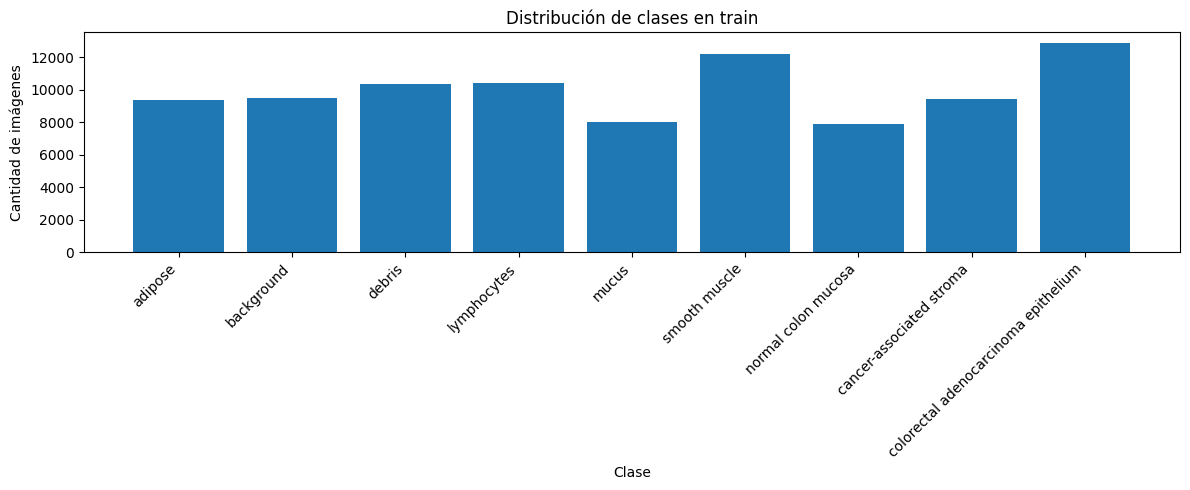

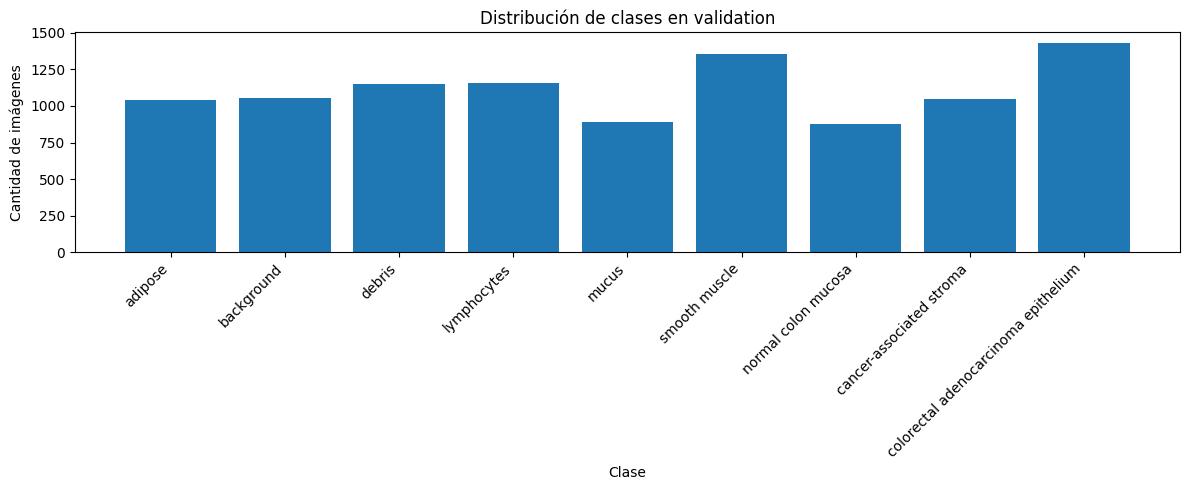

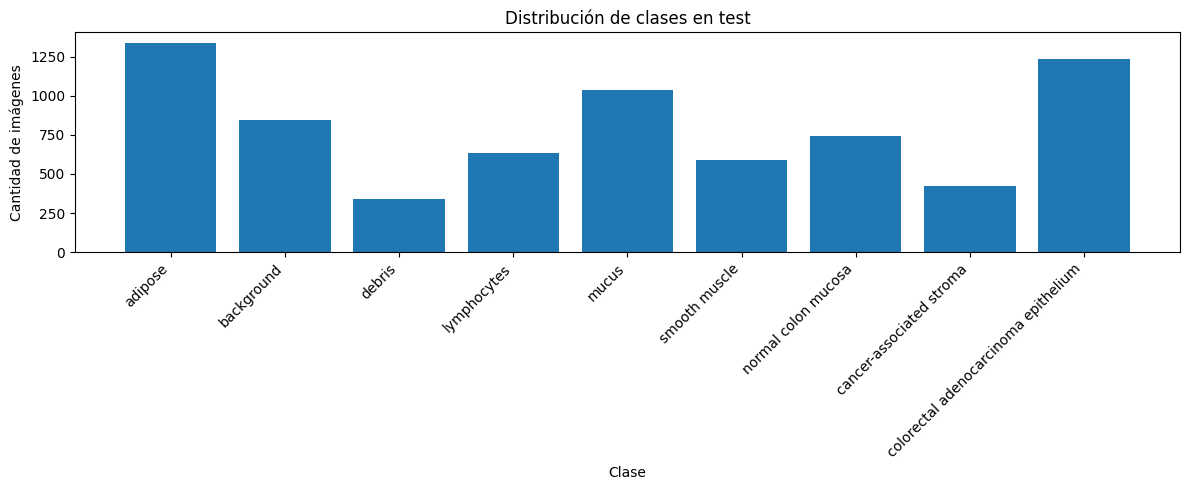

In [21]:
import matplotlib.pyplot as plt

for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[
        class_distribution_df["split"] == split_name
    ].sort_values("class_id")
    
    plt.figure(figsize=(12, 5))
    plt.bar(split_data["class_name"], split_data["count"])
    plt.title(f"Distribución de clases en {split_name}")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de imágenes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Comparación porcentual entre train, validation y test

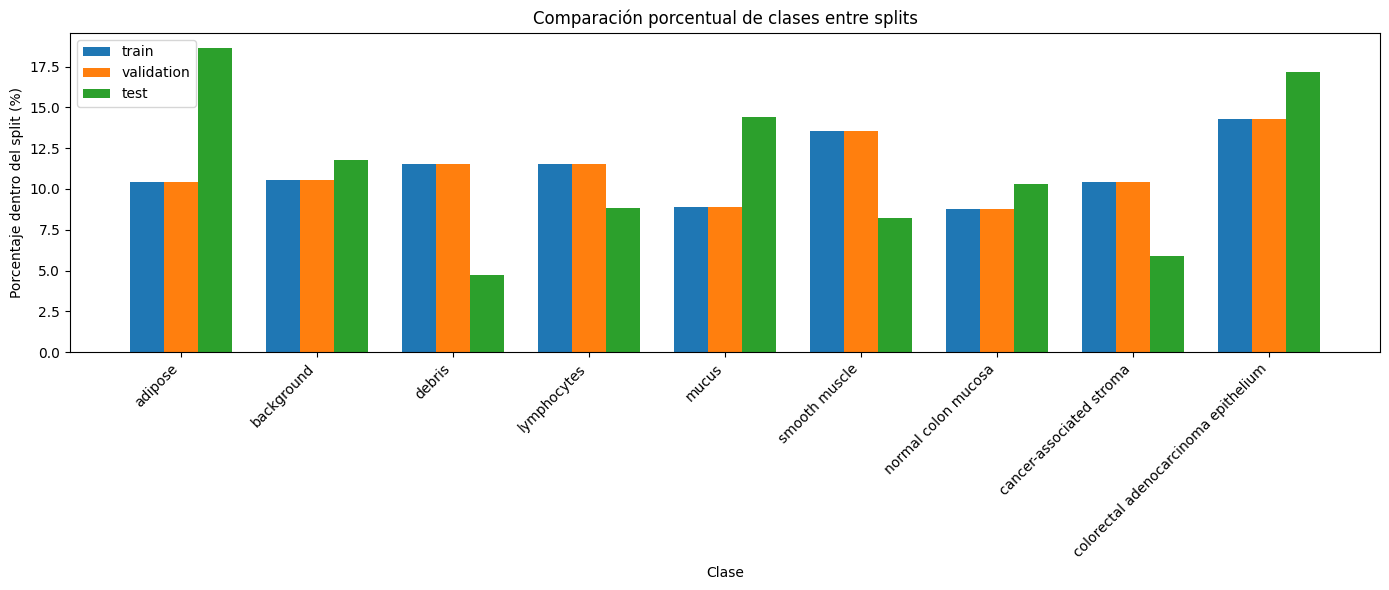

In [22]:
percentage_plot_df = class_percentage_pivot.copy()

x = np.arange(len(percentage_plot_df["class_name"]))
width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(x - width, percentage_plot_df["train"], width, label="train")
plt.bar(x, percentage_plot_df["validation"], width, label="validation")
plt.bar(x + width, percentage_plot_df["test"], width, label="test")

plt.title("Comparación porcentual de clases entre splits")
plt.xlabel("Clase")
plt.ylabel("Porcentaje dentro del split (%)")
plt.xticks(x, percentage_plot_df["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Diferencia porcentual respecto a train

In [23]:
split_difference_df = class_percentage_pivot.copy()

split_difference_df["validation_minus_train"] = (
    split_difference_df["validation"] - split_difference_df["train"]
)

split_difference_df["test_minus_train"] = (
    split_difference_df["test"] - split_difference_df["train"]
)

split_difference_display = split_difference_df[
    [
        "class_id",
        "class_name",
        "train",
        "validation",
        "test",
        "validation_minus_train",
        "test_minus_train"
    ]
].copy()

for column in ["train", "validation", "test", "validation_minus_train", "test_minus_train"]:
    split_difference_display[column] = split_difference_display[column].round(2)

display(split_difference_display)

split,class_id,class_name,train,validation,test,validation_minus_train,test_minus_train
0,0,adipose,10.41,10.41,18.64,-0.0,8.23
1,1,background,10.57,10.57,11.80,-0.0,1.23
2,2,debris,11.51,11.52,4.72,0.0,-6.79
3,3,lymphocytes,11.56,11.56,8.83,-0.0,-2.73
4,4,mucus,8.90,8.90,14.42,0.0,5.52
5,5,smooth muscle,13.54,13.53,8.25,-0.0,-5.29
6,6,normal colon mucosa,8.76,8.77,10.32,0.0,1.56
7,7,cancer-associated stroma,10.45,10.45,5.86,-0.0,-4.58
8,8,colorectal adenocarcinoma epithelium,14.32,14.31,17.17,-0.0,2.86


## Validaciones automáticas de distribución

In [24]:
for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]
    
    assert len(split_data) == n_classes, (
        f"Error en {split_name}: se esperaban {n_classes} clases, "
        f"pero se encontraron {len(split_data)}."
    )
    
    assert (split_data["count"] > 0).all(), (
        f"Error en {split_name}: existe al menos una clase sin muestras."
    )
    
    percentage_sum = split_data["percentage"].sum()
    
    assert np.isclose(percentage_sum, 100.0), (
        f"Error en {split_name}: los porcentajes no suman 100%. "
        f"Suma obtenida: {percentage_sum}."
    )

print("Validación de distribución superada: todas las clases están presentes en los tres splits y los porcentajes son consistentes.")

Validación de distribución superada: todas las clases están presentes en los tres splits y los porcentajes son consistentes.


## Conclusión de la Fase 4

El análisis de distribución de clases confirma que los tres splits oficiales de PathMNIST contienen las 9 clases esperadas. No se detectan clases ausentes en train, validation ni test, y las validaciones automáticas confirman que los porcentajes por split son consistentes.

En los conjuntos de **train** y **validation** se observa una distribución muy similar entre clases. Esto indica que validation conserva prácticamente la misma composición porcentual que train, por lo que resulta adecuado para monitorear el entrenamiento y apoyar la selección de hiperparámetros en etapas posteriores.

Sin embargo, el conjunto **test** presenta una distribución distinta y más desbalanceada. Mientras train y validation tienen un desbalance moderado, con ratios cercanos a 1.63, el conjunto test alcanza un `imbalance_ratio` de 3.947. En test, la clase mayoritaria es **adipose**, con 1.338 imágenes, mientras que la clase minoritaria es **debris**, con 339 imágenes.

Las diferencias porcentuales entre train y test son relevantes. Algunas clases aumentan considerablemente su representación en test, como **adipose** `(+8.23 puntos porcentuales)`, **mucus** `(+5.52)` y **colorectal adenocarcinoma epithelium** `(+2.86)`. En cambio, otras clases disminuyen de forma importante, como **debris** `(-6.79)`, **smooth muscle** `(-5.29)` y **cancer-associated stroma** `(-4.58)`.

Este hallazgo tiene una implicancia directa para la evaluación del modelo. Dado que test no conserva exactamente la misma distribución que train y validation, una métrica global como accuracy podría ocultar un bajo rendimiento en clases menos representadas. Por ello, en etapas posteriores será necesario complementar accuracy con métricas más informativas para clasificación multiclase, como **macro-F1**, **balanced accuracy**, **reporte por clase** y **matriz de confusión**.

En síntesis, PathMNIST presenta cobertura completa de clases en los tres splits, pero el conjunto test tiene una composición más desbalanceada y diferente respecto a train. Esta fase deja justificada la necesidad de evaluar el modelo no solo por desempeño global, sino también por desempeño específico en cada clase.

Con esto, el dataset queda caracterizado desde el punto de vista de soporte por clase.

# Fase 5 - Visualización cualitativa de imágenes

En esta fase se realiza una inspección visual inicial de las imágenes de PathMNIST.

El objetivo es observar ejemplos reales de las 9 clases del dataset para identificar patrones visuales preliminares, posibles similitudes entre clases y limitaciones asociadas a la resolución 28x28.

Esta fase responde las siguientes preguntas:

- ¿Cómo se ven las imágenes de cada clase?
- ¿Existen clases visualmente distinguibles?
- ¿Hay clases que parecen similares entre sí?
- ¿La resolución 28x28 conserva información suficiente para reconocer patrones generales?
- ¿Qué riesgos visuales podrían afectar el modelado posterior?

Esta fase no calcula todavía estadísticas RGB, no detecta anomalías de calidad de forma sistemática y no entrena modelos. Su propósito es entregar una primera lectura cualitativa del contenido visual del dataset.

## Imports para visualización

In [25]:
import matplotlib.pyplot as plt

## Función auxiliar para obtener etiquetas planas

In [26]:
def get_flat_labels(dataset):
    """
    Retorna las etiquetas de un split en formato plano.
    
    PathMNIST almacena las etiquetas con forma [N, 1].
    Para filtrar por clase, es más cómodo trabajar con forma [N].
    """
    
    return dataset.labels.reshape(-1)

## Función para seleccionar muestras por clase

In [27]:
def sample_indices_by_class(dataset, class_id, n_samples=6, seed=42):
    """
    Selecciona índices aleatorios de una clase específica dentro de un split.
    
    Parámetros:
    dataset: objeto PathMNIST.
    class_id: identificador numérico de la clase.
    n_samples: cantidad de imágenes a seleccionar.
    seed: semilla para reproducibilidad.
    
    Retorna:
    Array de índices seleccionados.
    """
    
    labels = get_flat_labels(dataset)
    class_indices = np.where(labels == class_id)[0]
    
    rng = np.random.default_rng(seed + int(class_id))
    
    sample_size = min(n_samples, len(class_indices))
    selected_indices = rng.choice(
        class_indices,
        size=sample_size,
        replace=False
    )
    
    return selected_indices

## Visualización de muestras por clase en train, validation y test

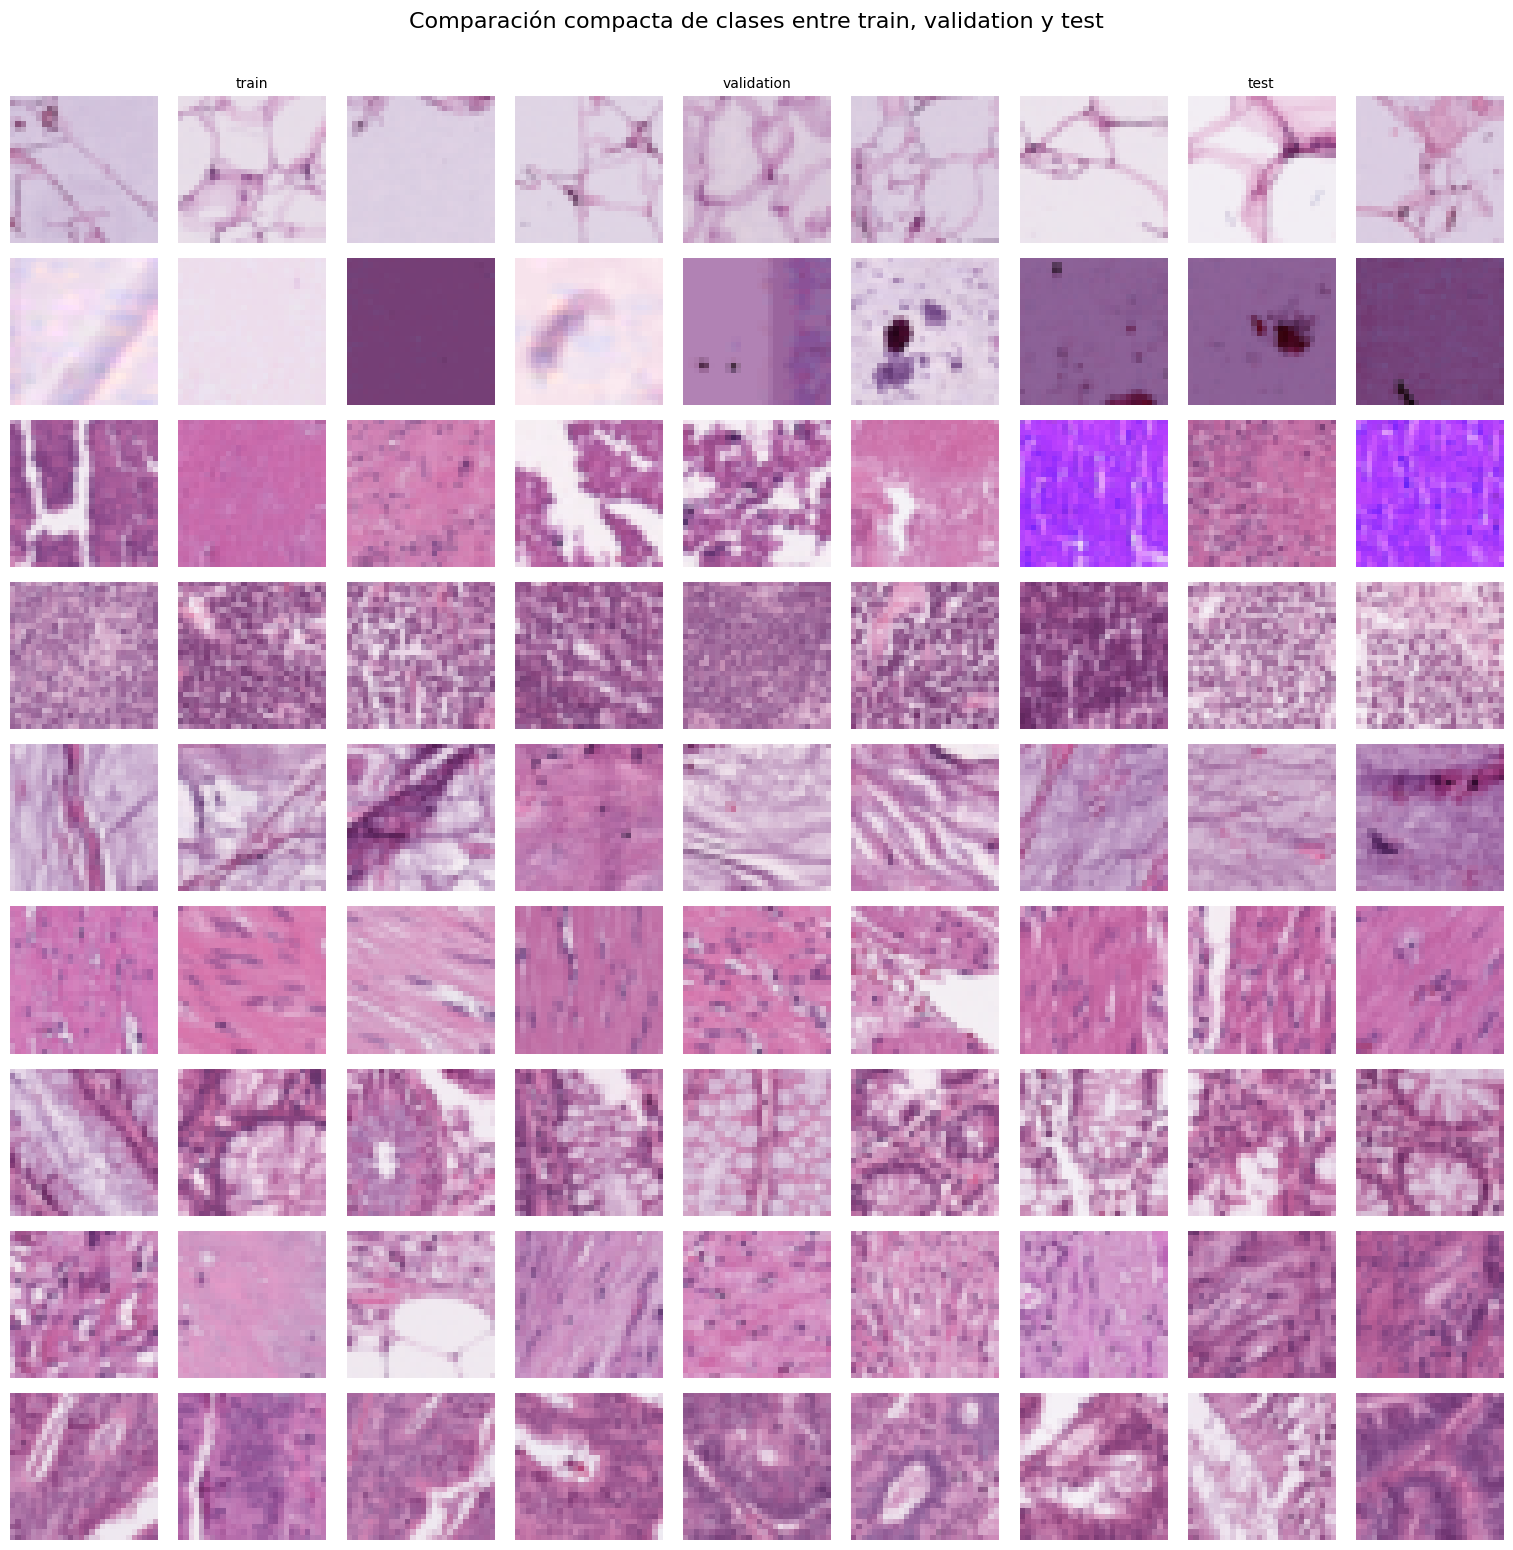

In [28]:
def plot_all_classes_across_splits(datasets, class_id_to_name, n_samples_per_split=3, seed=42):
    """
    Grafica una comparación compacta de todas las clases entre train, validation y test.

    Cada fila corresponde a una clase.
    Para cada clase se muestran muestras de train, validation y test.
    """

    split_names = ["train", "validation", "test"]
    n_classes_local = len(class_id_to_name)
    total_cols = len(split_names) * n_samples_per_split

    fig, axes = plt.subplots(
        nrows=n_classes_local,
        ncols=total_cols,
        figsize=(total_cols * 1.7, n_classes_local * 1.7)
    )

    for row_idx, (class_id, class_name) in enumerate(class_id_to_name.items()):
        for split_idx, split_name in enumerate(split_names):
            dataset = datasets[split_name]

            selected_indices = sample_indices_by_class(
                dataset=dataset,
                class_id=class_id,
                n_samples=n_samples_per_split,
                seed=seed + row_idx * 100 + split_idx * 10
            )

            for sample_idx in range(n_samples_per_split):
                col_idx = split_idx * n_samples_per_split + sample_idx
                ax = axes[row_idx, col_idx]

                if sample_idx < len(selected_indices):
                    image = dataset.imgs[selected_indices[sample_idx]]
                    ax.imshow(image)

                ax.axis("off")

                if row_idx == 0 and sample_idx == 1:
                    ax.set_title(split_name, fontsize=10)

                if col_idx == 0:
                    ax.set_ylabel(
                        f"{class_id}: {class_name}",
                        rotation=0,
                        labelpad=85,
                        va="center",
                        fontsize=9
                    )

    fig.suptitle(
        "Comparación compacta de clases entre train, validation y test",
        fontsize=16,
        y=1.01
    )

    plt.tight_layout()
    plt.show()


plot_all_classes_across_splits(
    datasets=datasets,
    class_id_to_name=class_id_to_name,
    n_samples_per_split=3,
    seed=SEED
)

## Visualización comparativa entre splits para una misma clase

In [29]:
def plot_class_across_splits(datasets, class_id, class_id_to_name, n_samples=5, seed=42):
    """
    Grafica muestras de una misma clase en train, validation y test.
    
    Cada fila corresponde a un split.
    Cada columna corresponde a una muestra aleatoria de la clase seleccionada.
    """
    
    split_names = ["train", "validation", "test"]
    class_name = class_id_to_name[class_id]
    
    fig, axes = plt.subplots(
        nrows=len(split_names),
        ncols=n_samples,
        figsize=(n_samples * 2.2, len(split_names) * 2.2)
    )
    
    for row_idx, split_name in enumerate(split_names):
        dataset = datasets[split_name]
        
        selected_indices = sample_indices_by_class(
            dataset=dataset,
            class_id=class_id,
            n_samples=n_samples,
            seed=seed + row_idx * 100
        )
        
        for col_idx in range(n_samples):
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(selected_indices):
                image = dataset.imgs[selected_indices[col_idx]]
                ax.imshow(image)
            
            ax.axis("off")
            
            if col_idx == 0:
                ax.set_ylabel(
                    split_name,
                    rotation=0,
                    labelpad=50,
                    va="center"
                )
    
    fig.suptitle(
        f"Comparación visual entre splits — Clase {class_id}: {class_name}",
        fontsize=15,
        y=1.02
    )
    
    plt.tight_layout()
    plt.show()

## Comparación entre splits para clases seleccionadas

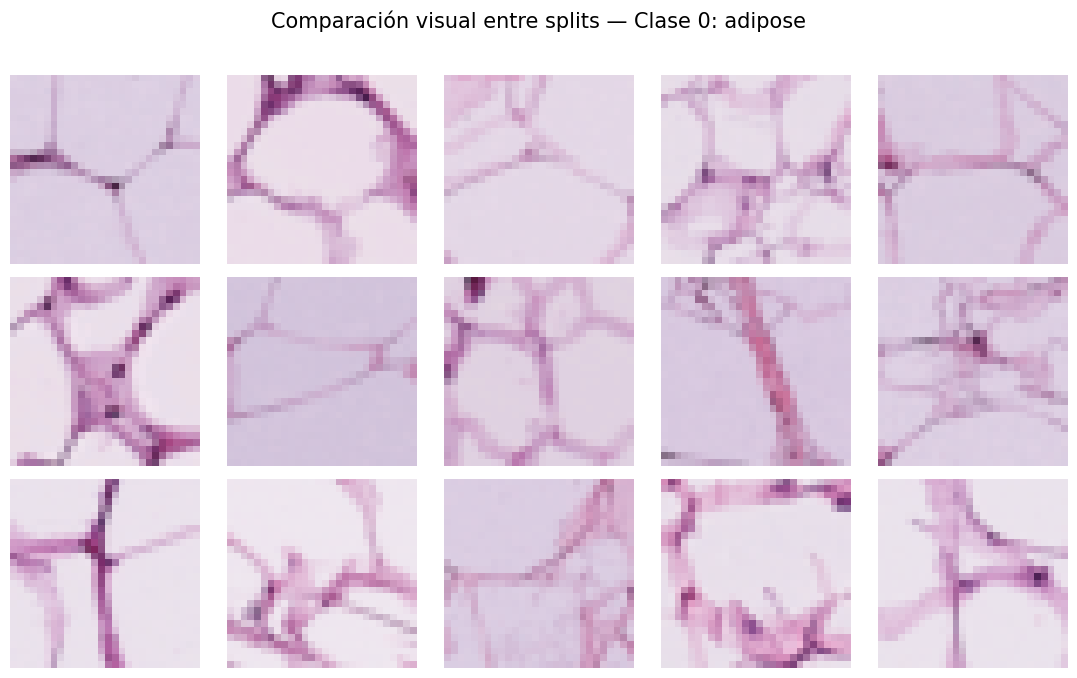

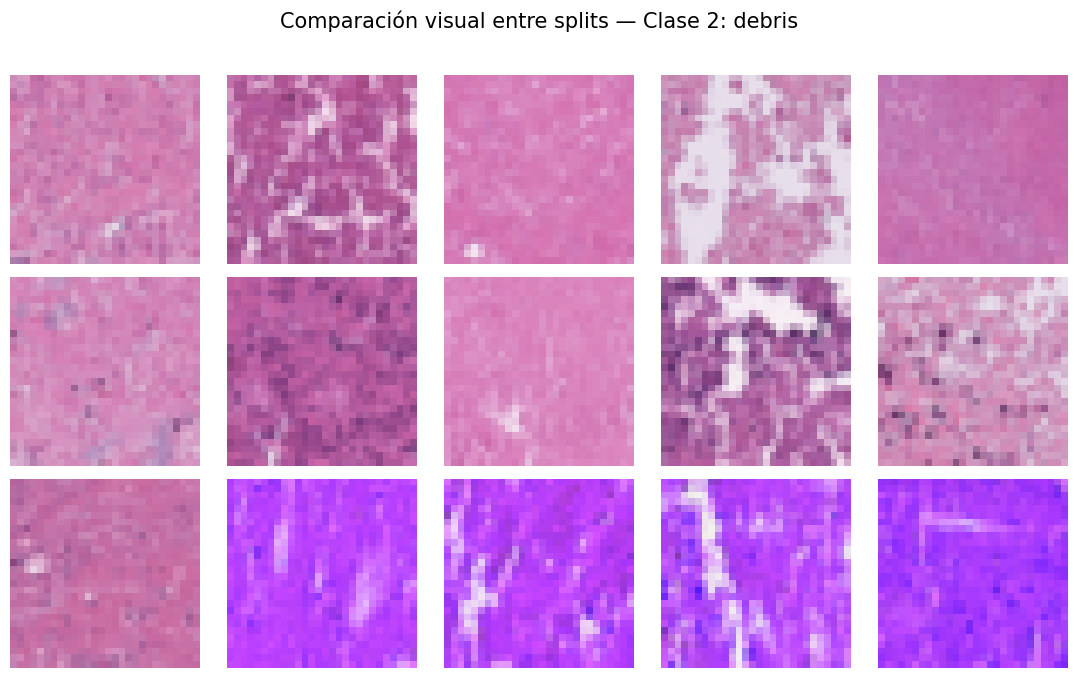

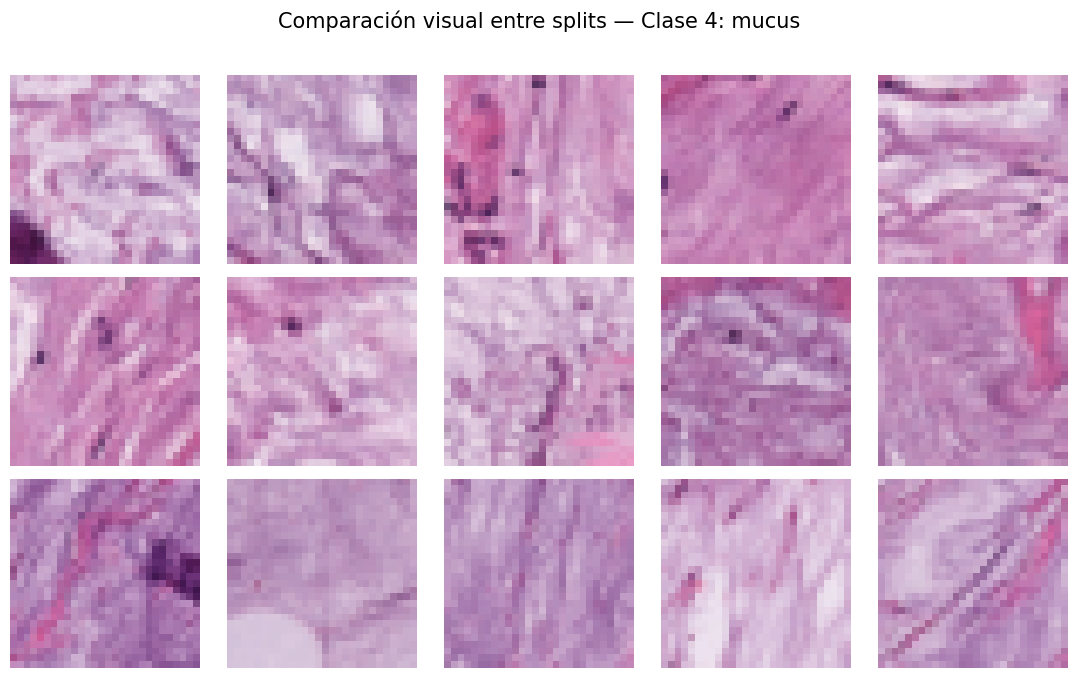

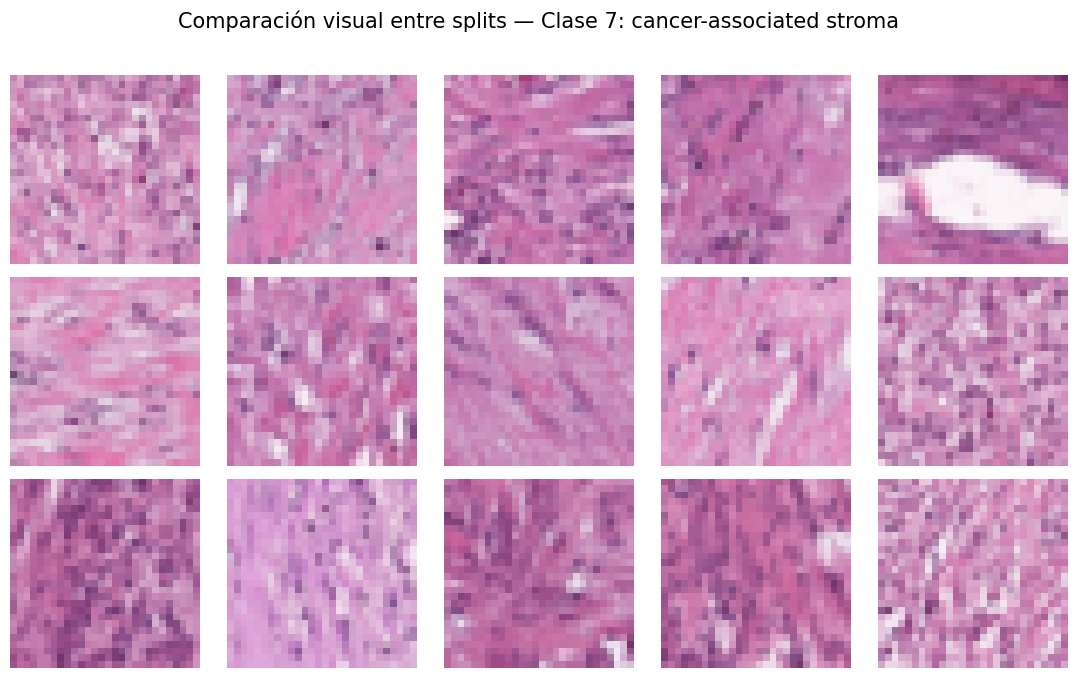

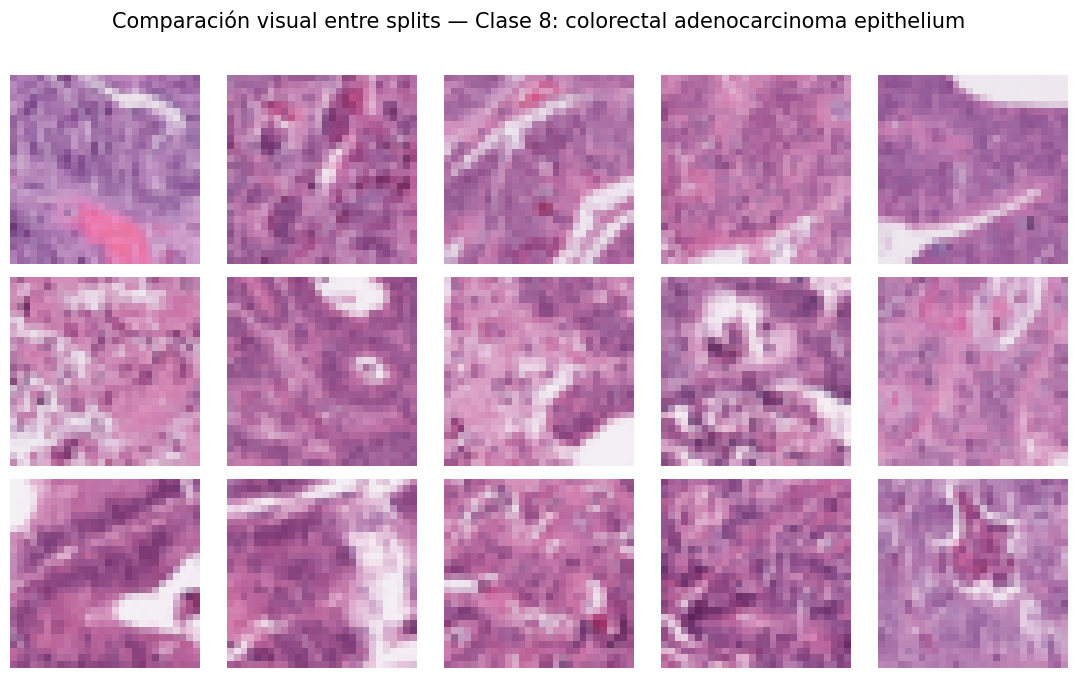

In [30]:
selected_classes_for_split_comparison = [
    0,  # adipose
    2,  # debris
    4,  # mucus
    7,  # cancer-associated stroma
    8   # colorectal adenocarcinoma epithelium
]

for class_id in selected_classes_for_split_comparison:
    plot_class_across_splits(
        datasets=datasets,
        class_id=class_id,
        class_id_to_name=class_id_to_name,
        n_samples=5,
        seed=SEED
    )

## Muestras aleatorias generales por split

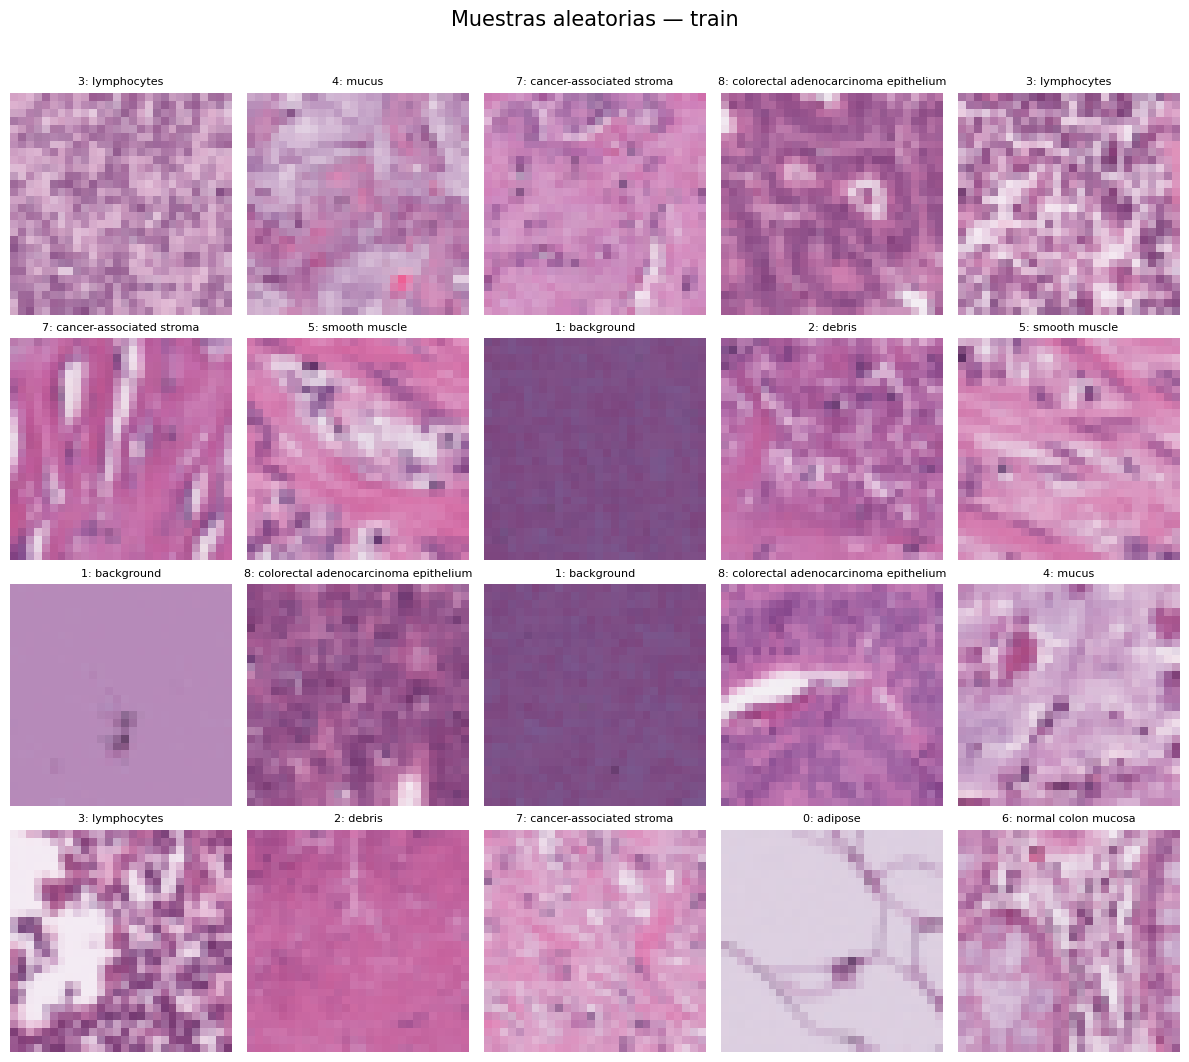

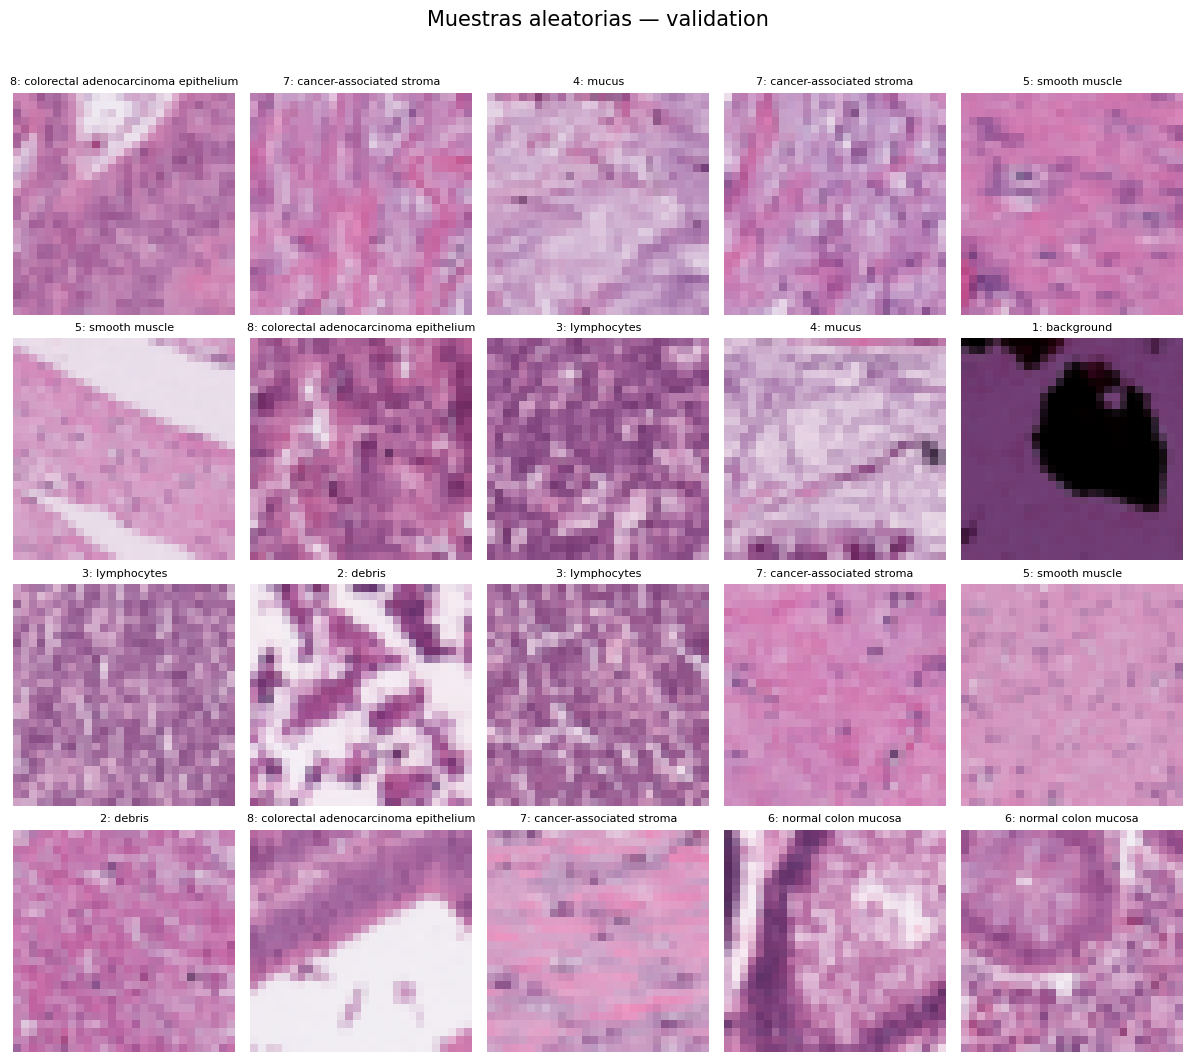

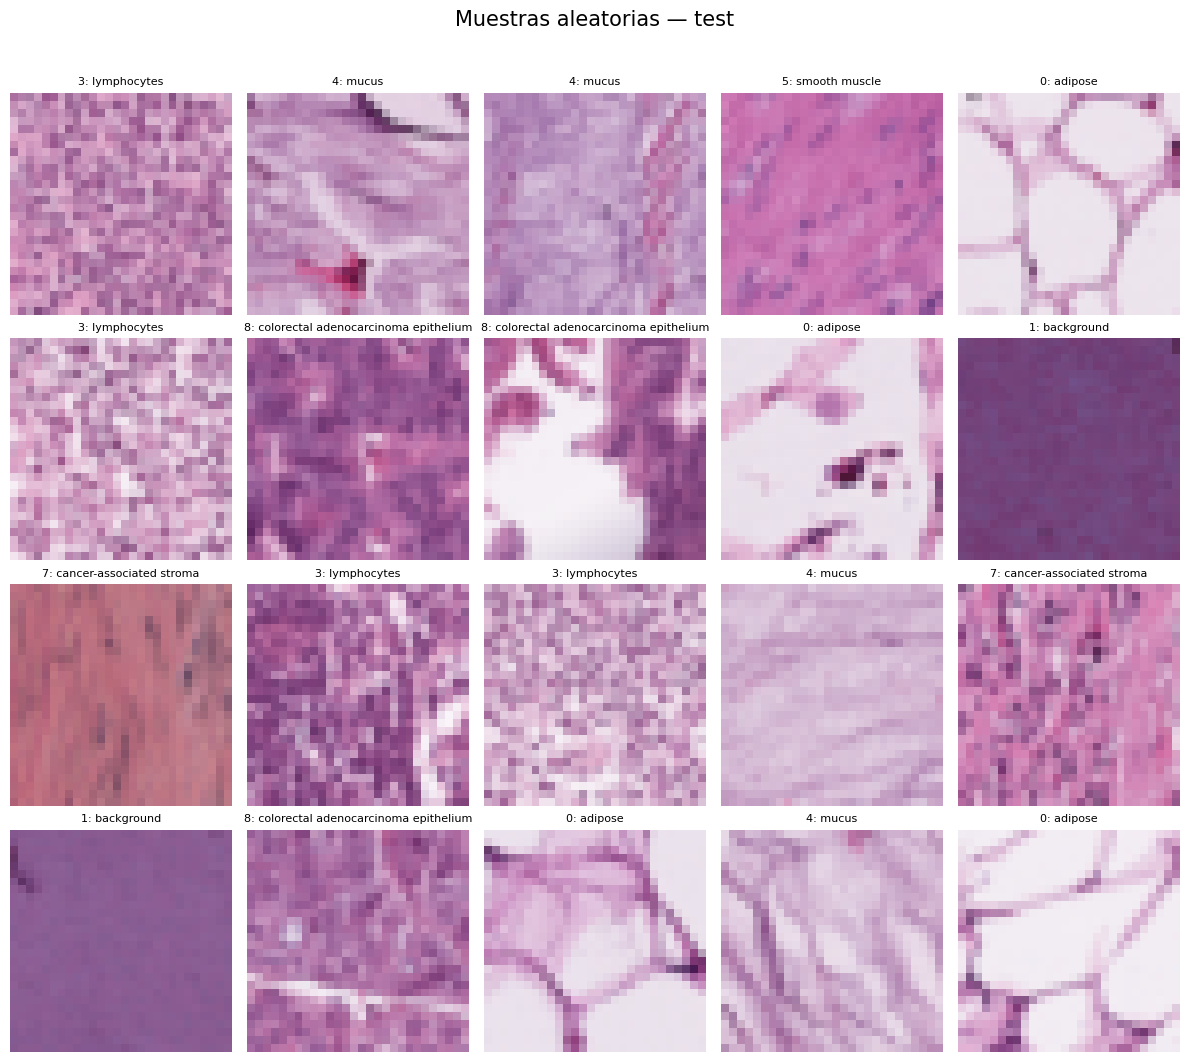

In [31]:
def plot_random_samples_from_split(dataset, split_name, class_id_to_name, n_samples=20, seed=42):
    """
    Grafica muestras aleatorias de un split, mostrando la clase asociada.
    """
    
    rng = np.random.default_rng(seed)
    total_samples = len(dataset.imgs)
    
    selected_indices = rng.choice(
        np.arange(total_samples),
        size=min(n_samples, total_samples),
        replace=False
    )
    
    n_cols = 5
    n_rows = int(np.ceil(len(selected_indices) / n_cols))
    
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(n_cols * 2.4, n_rows * 2.6)
    )
    
    axes = np.array(axes).reshape(-1)
    labels = get_flat_labels(dataset)
    
    for ax_idx, ax in enumerate(axes):
        if ax_idx < len(selected_indices):
            idx = selected_indices[ax_idx]
            image = dataset.imgs[idx]
            class_id = int(labels[idx])
            class_name = class_id_to_name[class_id]
            
            ax.imshow(image)
            ax.set_title(f"{class_id}: {class_name}", fontsize=8)
        
        ax.axis("off")
    
    fig.suptitle(
        f"Muestras aleatorias — {split_name}",
        fontsize=15,
        y=1.02
    )
    
    plt.tight_layout()
    plt.show()


plot_random_samples_from_split(
    dataset=train_dataset,
    split_name="train",
    class_id_to_name=class_id_to_name,
    n_samples=20,
    seed=SEED
)

plot_random_samples_from_split(
    dataset=val_dataset,
    split_name="validation",
    class_id_to_name=class_id_to_name,
    n_samples=20,
    seed=SEED
)

plot_random_samples_from_split(
    dataset=test_dataset,
    split_name="test",
    class_id_to_name=class_id_to_name,
    n_samples=20,
    seed=SEED
)

## Validación mínima de visualización

In [32]:
visual_check_rows = []

for split_name, dataset in datasets.items():
    images = dataset.imgs
    
    visual_check_rows.append({
        "split": split_name,
        "image_shape_per_sample": images.shape[1:],
        "compatible_with_imshow": images.ndim == 4 and images.shape[-1] == 3,
        "pixel_min": images.min(),
        "pixel_max": images.max()
    })

visual_check_df = pd.DataFrame(visual_check_rows)

display(visual_check_df)

,split,image_shape_per_sample,compatible_with_imshow,pixel_min,pixel_max
0,train,"(28, 28, 3)",True,0,255
1,validation,"(28, 28, 3)",True,0,255
2,test,"(28, 28, 3)",True,0,255


## Conclusión de la Fase 5

La visualización cualitativa de PathMNIST confirma que las imágenes conservan patrones visuales relevantes a pesar de trabajar con una resolución reducida de 28x28 píxeles. Aunque esta resolución limita el detalle histológico fino, todavía permite distinguir diferencias generales de color, textura, densidad celular y organización tisular que pueden ser útiles para el aprendizaje supervisado.

La comparación compacta de clases entre **train, validation y test** muestra que varias categorías mantienen una apariencia visual relativamente consistente a través de los tres splits. Por ejemplo, **adipose** presenta de forma recurrente grandes regiones claras separadas por bordes delgados rosados o violáceos, lo que la convierte en una clase visualmente bastante distinguible. De forma similar, **background** suele corresponder a regiones homogéneas o casi uniformes, con muy poca estructura tisular visible, lo que también sugiere una separación visual relativamente clara respecto a otras clases.

En contraste, clases como **debris**, **mucus**, **normal colon mucosa**, **cancer-associated stroma** y **colorectal adenocarcinoma epithelium** presentan una mayor variabilidad interna y también similitudes entre sí. Estas clases comparten, en distintos grados, texturas rosadas o violáceas, estructuras irregulares y niveles variables de densidad celular, lo que sugiere que el problema de clasificación no dependerá solamente de patrones morfológicos simples, sino de combinaciones más sutiles de textura, color y organización local.

La comparación entre splits también aporta información importante. En varias clases, la apariencia general se mantiene razonablemente estable entre train, validation y test; sin embargo, en otras se aprecian diferencias visuales que merecen atención. En particular, algunas muestras de **debris** en test muestran tonalidades más intensas o más cercanas al violeta que varios ejemplos observados en train y validation. Además, en la clase **background** aparecen ejemplos con regiones oscuras muy marcadas o áreas casi completamente uniformes, especialmente en validation y test. Estas observaciones no permiten concluir todavía la existencia de un cambio de dominio de forma definitiva, pero sí justifican que en las siguientes fases se analicen cuantitativamente las distribuciones de color, brillo e intensidad mediante estadísticas RGB y auditoría de calidad visual.

La visualización de muestras aleatorias por split refuerza dos ideas centrales. Primero, el dataset contiene clases con distinto nivel de complejidad visual: algunas son relativamente homogéneas, mientras que otras muestran una variabilidad considerable. Segundo, existen ejemplos extremos o poco representativos visualmente, como fondos muy oscuros, áreas casi uniformes o parches con contraste muy marcado. Estos casos no deben eliminarse en esta etapa, pero sí deben considerarse más adelante al revisar calidad de datos y posibles outliers visuales.

Un hallazgo adicional importante es que varias clases potencialmente relevantes para el problema clínico, como **cancer-associated stroma**, **normal colon mucosa** y **colorectal adenocarcinoma epithelium**, muestran patrones que pueden resultar visualmente cercanos en resolución 28x28. Esto sugiere que el modelo podría tener mayores dificultades para separar clases histológicamente complejas o con fronteras visuales sutiles, en comparación con clases más fácilmente distinguibles como **adipose** o **background**.

La validación mínima de visualización confirma además que las imágenes de train, validation y test tienen forma `(28, 28, 3)`, son compatibles con visualización directa y conservan valores de píxel entre 0 y 255. Esto asegura que las observaciones cualitativas realizadas corresponden a los datos originales cargados, sin transformaciones de normalización ni preprocesamiento adicional.

En síntesis, la inspección visual confirma que PathMNIST contiene señales visuales suficientes para tareas de clasificación, pero también evidencia tres aspectos clave:  
1. la resolución 28x28 conserva patrones generales, aunque limita el detalle histológico fino;  
2. algunas clases son visualmente más distinguibles que otras;  
3. existen variaciones visuales y posibles diferencias cromáticas entre splits que deberán analizarse cuantitativamente más adelante.

Con esto, el dataset queda caracterizado desde una perspectiva visual preliminar y preparado para la siguiente fase del EDA: **Fase 8 — Estadísticas globales de píxeles y canales RGB**.++

# Fase 6 - Distribución de clases y análisis de soporte

En esta fase se realiza un análisis cuantitativo del balance de las clases a través de las distintas particiones del dataset (entrenamiento, validación y prueba).

El objetivo es medir la proporción de imágenes por categoría, evaluar el grado de desbalance mediante el ratio entre la clase mayoritaria y minoritaria, y comprobar la consistencia de la distribución estadística en los diferentes splits.

Esta fase responde las siguientes preguntas:

-¿Cuántas imágenes hay por cada clase en los distintos conjuntos?

-¿Existe un desbalance significativo entre las categorías mayoritarias y minoritarias?

-¿Se mantiene la misma proporción de clases de forma consistente entre entrenamiento, validación y prueba?

-¿Es la métrica de accuracy (exactitud) confiable por sí sola para evaluar el modelo posterior?

-¿Qué implicancias tiene la advertencia oficial de Zenodo sobre la naturaleza de este dataset?

Esta fase no aplica técnicas algorítmicas para corregir el desbalance (como oversampling, undersampling o pesos en la función de pérdida), ni altera los datos originales. Su propósito es demostrar empíricamente que la partición de los datos (hold-out) es estadísticamente coherente y justificar la necesidad de usar métricas complementarias robustas para la evaluación del modelo.

## Extraer las etiquetas de cada split y aplanarlas a un array 1D

In [33]:
y_train = train_dataset.labels.flatten()
y_val = val_dataset.labels.flatten()
y_test = test_dataset.labels.flatten()

# Función auxiliar para calcular estadísticas (conteo, porcentaje y ratio)
def obtener_estadisticas(y):
    clases, conteos = np.unique(y, return_counts=True)
    porcentajes = (conteos / len(y)) * 100
    ratio = np.max(conteos) / np.min(conteos)
    return clases, conteos, porcentajes, ratio

# Calcular métricas para cada split
clases, count_train, perc_train, ratio_train = obtener_estadisticas(y_train)
_, count_val, perc_val, ratio_val = obtener_estadisticas(y_val)
_, count_test, perc_test, ratio_test = obtener_estadisticas(y_test)

## Imprimir Conteo, Porcentaje y Ratio por split

In [34]:
splits = [("Train", count_train, perc_train, ratio_train),
          ("Validation", count_val, perc_val, ratio_val),
          ("Test", count_test, perc_test, ratio_test)]

for nombre, counts, percs, ratio in splits:
    print(f"--- Distribución en {nombre} ---")
    for c, count, p in zip(clases, counts, percs):
        print(f"Clase {c}: {count} muestras ({p:.2f}%)")
    print(f"Ratio Mayoritaria/Minoritaria: {ratio:.2f}\n")

--- Distribución en Train ---
Clase 0: 9366 muestras (10.41%)
Clase 1: 9509 muestras (10.57%)
Clase 2: 10360 muestras (11.51%)
Clase 3: 10401 muestras (11.56%)
Clase 4: 8006 muestras (8.90%)
Clase 5: 12182 muestras (13.54%)
Clase 6: 7886 muestras (8.76%)
Clase 7: 9401 muestras (10.45%)
Clase 8: 12885 muestras (14.32%)
Ratio Mayoritaria/Minoritaria: 1.63

--- Distribución en Validation ---
Clase 0: 1041 muestras (10.41%)
Clase 1: 1057 muestras (10.57%)
Clase 2: 1152 muestras (11.52%)
Clase 3: 1156 muestras (11.56%)
Clase 4: 890 muestras (8.90%)
Clase 5: 1354 muestras (13.53%)
Clase 6: 877 muestras (8.77%)
Clase 7: 1045 muestras (10.45%)
Clase 8: 1432 muestras (14.31%)
Ratio Mayoritaria/Minoritaria: 1.63

--- Distribución en Test ---
Clase 0: 1338 muestras (18.64%)
Clase 1: 847 muestras (11.80%)
Clase 2: 339 muestras (4.72%)
Clase 3: 634 muestras (8.83%)
Clase 4: 1035 muestras (14.42%)
Clase 5: 592 muestras (8.25%)
Clase 6: 741 muestras (10.32%)
Clase 7: 421 muestras (5.86%)
Clase 8: 123

## Comparación de proporciones entre splits (Formato Tabla)

In [35]:
df_prop = pd.DataFrame({
    'Clase': clases,
    'Train (%)': perc_train,
    'Val (%)': perc_val,
    'Test (%)': perc_test
})
print("--- Comparación de Proporciones entre Splits ---")
print(df_prop.round(2).to_string(index=False))
print("\n")

--- Comparación de Proporciones entre Splits ---
 Clase  Train (%)  Val (%)  Test (%)
     0      10.41    10.41     18.64
     1      10.57    10.57     11.80
     2      11.51    11.52      4.72
     3      11.56    11.56      8.83
     4       8.90     8.90     14.42
     5      13.54    13.53      8.25
     6       8.76     8.77     10.32
     7      10.45    10.45      5.86
     8      14.32    14.31     17.17




## Gráficos

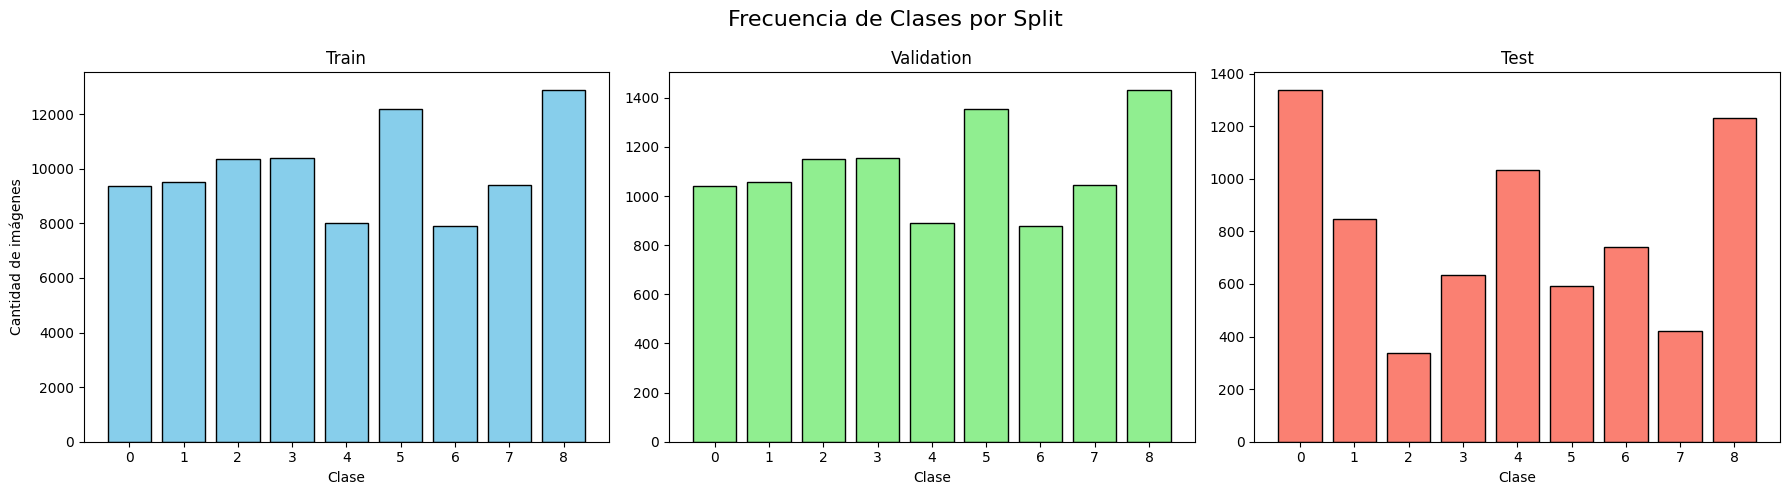

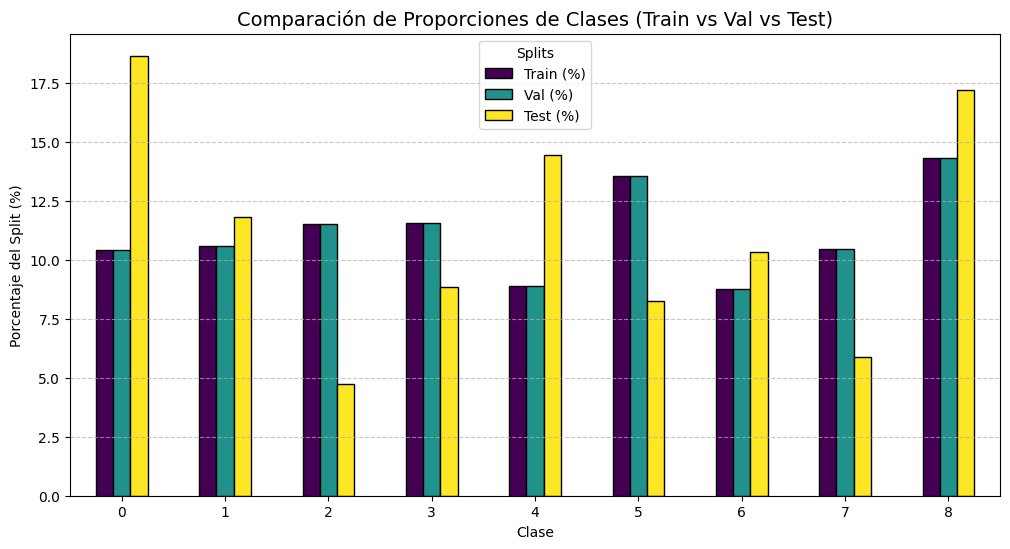

In [36]:
# Gráfico A: Gráfico de barras por split individual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Frecuencia de Clases por Split', fontsize=16)

# Entrenamieto
axes[0].bar(clases, count_train, color='skyblue', edgecolor='black')
axes[0].set_title('Train')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].set_xticks(clases)

# Validación
axes[1].bar(clases, count_val, color='lightgreen', edgecolor='black')
axes[1].set_title('Validation')
axes[1].set_xlabel('Clase')
axes[1].set_xticks(clases)

# Prueba
axes[2].bar(clases, count_test, color='salmon', edgecolor='black')
axes[2].set_title('Test')
axes[2].set_xlabel('Clase')
axes[2].set_xticks(clases)

plt.tight_layout()
plt.show()

# Gráfico B: Gráfico comparativo de proporciones (Train/Val/Test)
df_prop.plot(x='Clase', y=['Train (%)', 'Val (%)', 'Test (%)'], kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title('Comparación de Proporciones de Clases (Train vs Val vs Test)', fontsize=14)
plt.ylabel('Porcentaje del Split (%)')
plt.xlabel('Clase')
plt.xticks(rotation=0)
plt.legend(title='Splits')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusión de la Fase 6

La evaluación cuantitativa de la distribución de clases en PathMNIST confirma que el dataset presenta un desbalance moderado pero evidente. Aunque no existen categorías minoritarias extremas que imposibiliten el aprendizaje, las diferencias en el volumen de imágenes (soporte) entre los distintos tipos de tejidos son suficientes para requerir un manejo metodológico riguroso durante la evaluación del modelo.

El análisis de conteos y porcentajes revela que clases como **colorectal adenocarcinoma epithelium** y **smooth muscle** actúan sistemáticamente como las categorías mayoritarias. Por el contrario, tejidos como **normal colon mucosa** y **mucus** presentan una representación notablemente menor dentro del conjunto de datos. Esta dinámica genera un ratio entre la clase mayoritaria y la minoritaria que, si bien no es crítico, impide asumir una distribución estadística perfectamente uniforme en el problema de clasificación.

Un hallazgo fundamental y sumamente positivo de esta fase es la alta consistencia de las proporciones a través de los conjuntos de **train, validation y test**. La comparación entre los *splits* demuestra que la estructura distributiva de las 9 clases se mantiene estable de forma casi idéntica. Esto confirma que la partición de los datos (hold-out) oficial es estadísticamente coherente y representativa. Esta consistencia es vital para el diseño experimental, ya que asegura que el rendimiento medido en las fases de validación y prueba reflejará de manera justa lo aprendido durante el entrenamiento, sin sesgos introducidos por asimetrías en la división de los datos.

Desde la perspectiva del modelado, este desbalance natural tiene implicancias directas sobre los criterios de evaluación. Tal como advierte explícitamente la documentación oficial de MedMNIST (Zenodo), las clases en este dataset están solo *aproximadamente balanceadas*. Por lo tanto, depender exclusivamente de la métrica de *accuracy* (exactitud) representa un riesgo analítico: un modelo podría obtener un rendimiento aparentemente alto simplemente aprendiendo a predecir con mayor frecuencia las clases mayoritarias, penalizando el reconocimiento de tejidos menos representados pero de igual importancia clínica.

En síntesis, el análisis de soporte valida la integridad de las particiones de datos, pero también evidencia tres aspectos clave para el desarrollo del algoritmo:
1. el desbalance moderado de las clases invalida el uso del *accuracy* como única métrica de éxito;
2. la proporción de imágenes se mantiene constante entre train, validation y test, lo que garantiza una evaluación justa y sin sesgos de partición;
3. es estrictamente necesario incorporar métricas complementarias robustas, como el *Macro F1-Score* o el *AUROC*, que asignen un peso equitativo a todas las clases y penalicen al modelo si ignora las categorías minoritarias.

Con esto, la estructura cuantitativa de las etiquetas queda caracterizada y justificada desde una perspectiva estadística, dejando el terreno preparado para el inicio del diseño experimental: **Fase 7 — Preparación de los DataLoaders y Definición de Métricas**.

# Fase 7 — Visualización cualitativa de imágenes

En esta fase se realiza una inspección visual de las imágenes de PathMNIST a lo largo de las tres particiones del conjunto de datos. 

El objetivo es observar el contenido visual real por clase para identificar patrones, evaluar la coherencia de las imágenes con el problema médico declarado y analizar las limitaciones introducidas por la resolución de 28x28 píxeles.

Esta fase responde a las siguientes interrogantes:
* ¿Cómo se estructuran visualmente las muestras en los conjuntos de entrenamiento, validación y prueba?
* ¿Cuáles son las características morfológicas, de color y de textura que definen a cada clase?
* ¿Qué clases presentan señales visuales fácilmente distinguibles?
* ¿Qué clases comparten atributos visuales que podrían generar confusiones durante el modelado?

La inspección cualitativa es un paso indispensable en visión artificial para validar la correspondencia entre los datos y la tarea clínica antes de entrenar cualquier modelo.

## Mapa de clases

In [37]:
from PIL import Image

In [38]:
label_class_map = {
    0: 'adipose', 1: 'background', 2: 'debris', 3: 'lymphocytes', 
    4: 'mucus', 5: 'smooth muscle', 6: 'normal colon mucosa', 
    7: 'cancer-associated stroma', 8: 'colorectal adenocarcinoma epithelium'
}

# Función auxiliar para mostrar muestras aleatorias de un split
def mostrar_muestras_aleatorias(dataset, titulo, num_muestras=6):
    fig, axes = plt.subplots(1, num_muestras, figsize=(15, 3))
    fig.suptitle(titulo, fontsize=14)
    
    # Seleccionar índices aleatorios
    indices = np.random.choice(len(dataset), num_muestras, replace=False)
    
    for i, idx in enumerate(indices):
        img_data, label = dataset[idx]
        
        # --- FIX: Manejo dinámico del formato de la imagen ---
        if isinstance(img_data, torch.Tensor):
            img = img_data.permute(1, 2, 0).numpy() # Si es Tensor, permutar canales
        else:
            img = np.array(img_data) # Si es PIL Image, convertir a array
        # -----------------------------------------------------
            
        label_id = int(label[0])
        
        axes[i].imshow(img)
        axes[i].set_title(f"{label_class_map[label_id]}\n(Clase {label_id})", fontsize=9)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

## Grillas

--- Muestras Aleatorias por Split ---


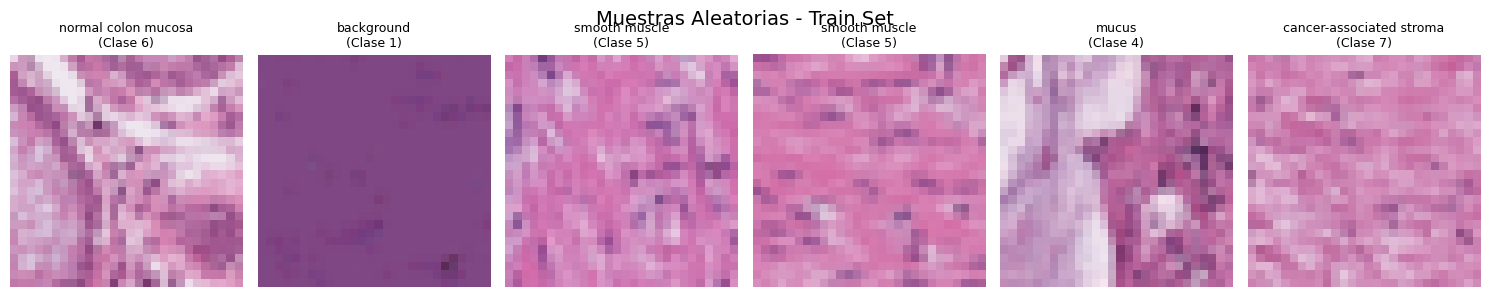

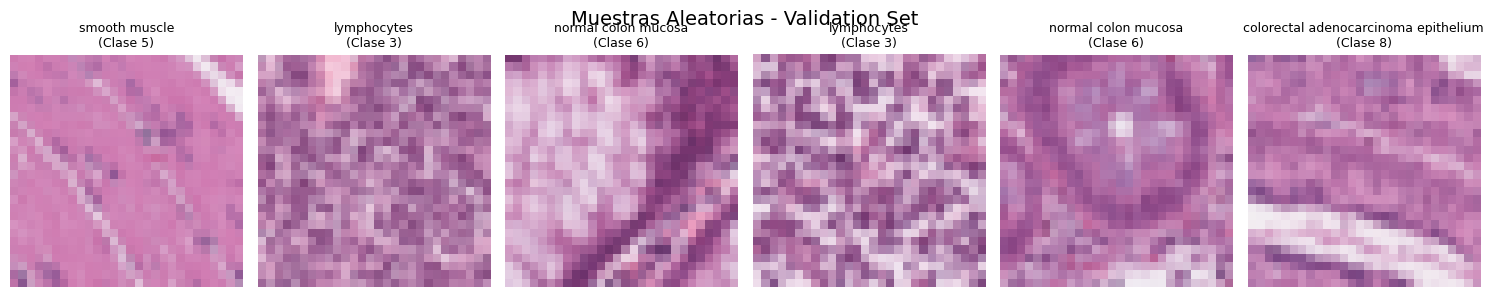

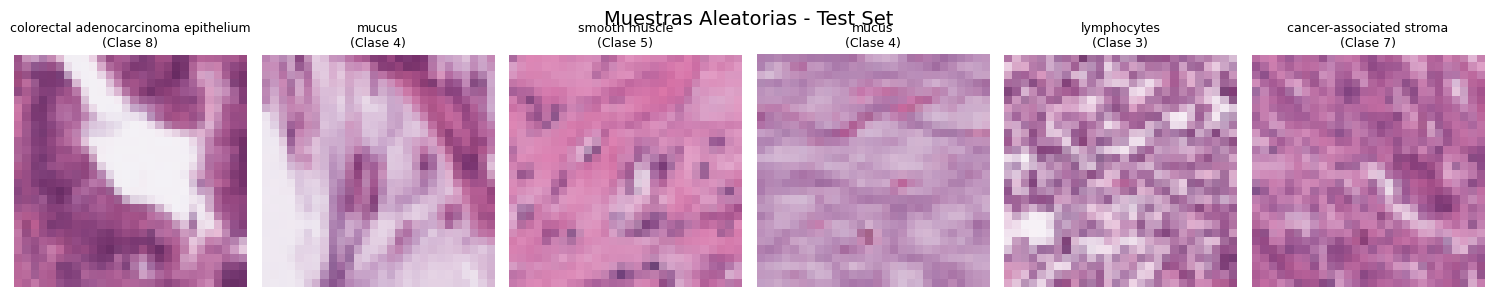

--- Grilla de Muestras por Clase ---


Text(0.5, 0.98, 'Ejemplos Representativos por Clase (PathMNIST)')

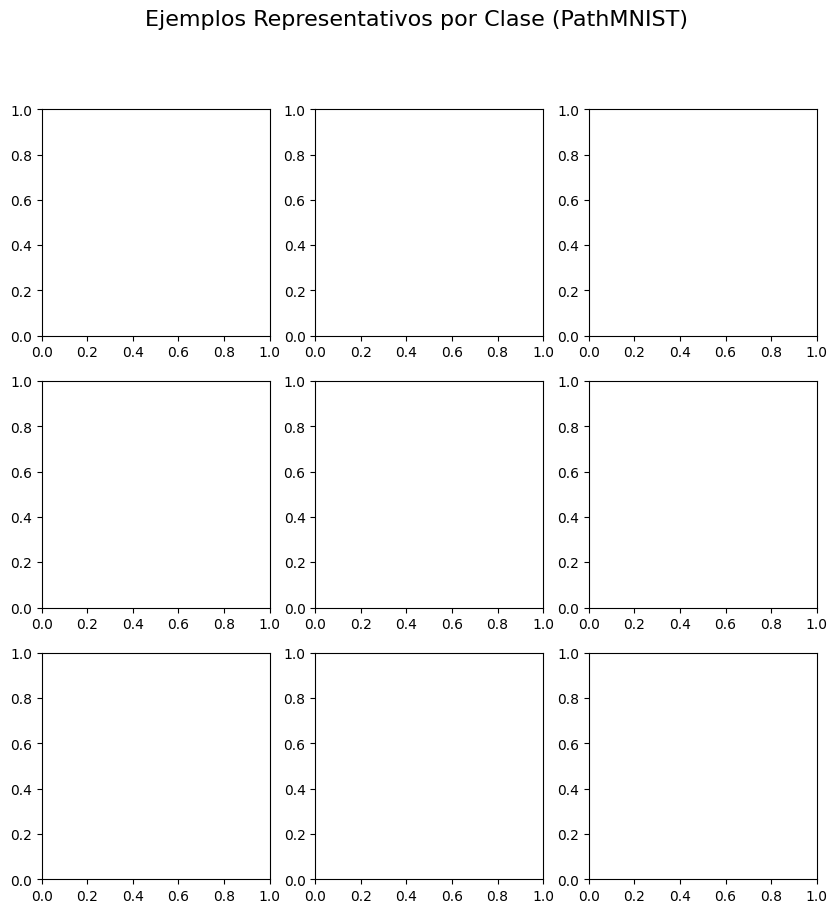

In [39]:
# 1. Grillas de muestras aleatorias por split
print("--- Muestras Aleatorias por Split ---")
mostrar_muestras_aleatorias(train_dataset, "Muestras Aleatorias - Train Set")
mostrar_muestras_aleatorias(val_dataset, "Muestras Aleatorias - Validation Set")
mostrar_muestras_aleatorias(test_dataset, "Muestras Aleatorias - Test Set")

# 2. Grilla representativa por clase (1 ejemplo por clase)
print("--- Grilla de Muestras por Clase ---")
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Ejemplos Representativos por Clase (PathMNIST)', fontsize=16)

# Extraer la primera aparición de cada clase en el train_dataset

In [40]:
imagenes_por_clase = {}
idx = 0
while len(imagenes_por_clase) < 9:
    img_data, label = train_dataset[idx]
    label_id = int(label[0])
    
    if label_id not in imagenes_por_clase:
        # --- FIX: Manejo dinámico del formato para la grilla ---
        if isinstance(img_data, torch.Tensor):
            imagenes_por_clase[label_id] = img_data.permute(1, 2, 0).numpy()
        else:
            imagenes_por_clase[label_id] = np.array(img_data)
        # -------------------------------------------------------
    idx += 1

# Graficar la cuadrícula 3x3

In [41]:
for label_id, ax in zip(range(9), axes.flatten()):
    ax.imshow(imagenes_por_clase[label_id])
    ax.set_title(f"{label_class_map[label_id]} (Clase {label_id})", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### Comentario visual por clase e identificación de complejidad

A partir de las grillas generadas, se puede establecer una categorización preliminar de la dificultad que enfrentará el modelo para discriminar los tejidos:

**Clases potencialmente fáciles (Alta distinguibilidad):**
* **Adipose (0):** Destaca por sus grandes espacios en blanco (vacuolas de grasa) delineados por membranas finas. Su estructura geométrica y falta de coloración densa la hacen muy particular.
* **Background (1):** Principalmente áreas claras, uniformes y sin estructuras tisulares ni densidad celular, fácilmente separables del resto.
* **Mucus (4):** Exhibe texturas amorfas, a menudo con coloraciones pálidas o azuladas/violáceas tenues que contrastan con la densidad de otros tejidos.

**Clases potencialmente difíciles (Alta similitud y confusión):**
* **Normal colon mucosa (6) y Colorectal adenocarcinoma epithelium (8):** Ambas presentan formaciones glandulares y una alta densidad celular (píxeles oscuros/morados). La diferencia radica en la organización estructural, que a resolución 28x28 pierde gran parte de su nitidez, haciendo que se superpongan visualmente.
* **Smooth muscle (5) y Cancer-associated stroma (7):** Ambas muestran tejidos conectivos densos, fibrosos y fuertemente teñidos de rosa (eosina). Las variaciones morfológicas son sutiles, basándose más en la direccionalidad de las fibras que en cambios bruscos cromáticos.
* **Debris (2) y Lymphocytes (3):** Suelen presentar agrupaciones de núcleos oscuros y densos. A baja resolución, el detrito celular puede asemejarse visualmente a cúmulos linfocitarios debido a la fragmentación de la información espacial.

## Conclusión de la Fase 7

El análisis cualitativo confirma que las imágenes de los tres *splits* corresponden fielmente al dominio del problema histopatológico, manteniendo una coherencia visual adecuada a través del conjunto de datos. Como se observa en las grillas, algunas clases presentan señales visuales distinguibles, pero otras comparten textura, color o morfología, lo que anticipa confusiones. 

Esta exploración es metodológicamente indispensable; la rúbrica del proyecto exige evidencias visuales y, en visión artificial, la inspección humana es el paso definitivo para validar la integridad de los datos antes de inyectarlos en una red neuronal. El reconocimiento de estas superposiciones morfológicas a resolución 28x28 justifica la posterior implementación de arquitecturas más robustas, como los Transformers Visuales, que podrían capturar mejor las relaciones espaciales complejas que una CNN convencional podría pasar por alto.

# Fase 8 — Estadísticas globales de píxeles y canales RGB

En esta fase se calculan las estadísticas descriptivas de los valores de intensidad de los píxeles para los canales Rojo (R), Verde (G) y Azul (B) en el conjunto de entrenamiento, y se comparan con los conjuntos de validación y prueba.

El objetivo es entender la distribución cromática y de intensidades del dataset para preparar el proceso de normalización de las imágenes. 

Esta fase incluye:
* Cálculo de la media global, desviación estándar, mínimo y máximo por canal RGB en el conjunto de entrenamiento.
* Histogramas de distribución de intensidad para cada canal.
* Una tabla comparativa de las estadísticas RGB entre *train*, *validation* y *test*.

En imágenes histopatológicas (como las de PathMNIST), el color no es un factor arbitrario; las tinciones químicas (como Hematoxilina y Eosina) generan firmas cromáticas específicas por tipo de tejido. Conocer esta distribución es fundamental para estandarizar los datos y ayudar al modelo a converger más rápido.

## Creamos los DataLoaders

In [42]:
from torchvision import transforms
from medmnist import PathMNIST
from torch.utils.data import DataLoader

# 1. Definimos la transformación obligatoria a Tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Volvemos a cargar los datasets aplicando el transform explícitamente
train_dataset = PathMNIST(split="train", transform=transform, download=True, size=28)
val_dataset   = PathMNIST(split="val", transform=transform, download=True, size=28)
test_dataset  = PathMNIST(split="test", transform=transform, download=True, size=28)

# 3. Volvemos a crear los DataLoaders
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print("Datasets y DataLoaders recargados en formato Tensor correctamente.")

Datasets y DataLoaders recargados en formato Tensor correctamente.


In [43]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders creados con éxito:")
print(f"Lotes en train: {len(train_loader)}")
print(f"Lotes en validation: {len(val_loader)}")
print(f"Lotes en test: {len(test_loader)}")

DataLoaders creados con éxito:
Lotes en train: 1407
Lotes en validation: 157
Lotes en test: 113


## Función para calcular estadísticas exactas por canal usando un DataLoader

In [44]:
def calcular_estadisticas_rgb(dataloader):
    suma_canales = torch.zeros(3)
    suma_cuadrados_canales = torch.zeros(3)
    min_val = torch.ones(3) * float('inf')
    max_val = torch.ones(3) * float('-inf')
    total_pixeles = 0
    
    for imagenes, _ in dataloader:
        # imagenes tiene forma [batch_size, 3, 28, 28]
        b, c, h, w = imagenes.shape
        num_pixeles_batch = b * h * w
        
        # Aplanamos las dimensiones espaciales y de batch para que quede forma [3, N]
        imagenes_flat = imagenes.transpose(0, 1).reshape(3, -1)
        
        # Sumas para la media y desviación estándar
        suma_canales += torch.sum(imagenes_flat, dim=1)
        suma_cuadrados_canales += torch.sum(imagenes_flat ** 2, dim=1)
        total_pixeles += num_pixeles_batch
        
        # Mínimos y máximos iterativos (ahora calculados sobre la dimensión 1 plana)
        min_batch = torch.min(imagenes_flat, dim=1).values
        max_batch = torch.max(imagenes_flat, dim=1).values
        
        min_val = torch.minimum(min_val, min_batch)
        max_val = torch.maximum(max_val, max_batch)
    # Calcular media y desviación estándar
    media = suma_canales / total_pixeles
    desviacion_std = torch.sqrt((suma_cuadrados_canales / total_pixeles) - (media ** 2))

    return media.numpy(), desviacion_std.numpy(), min_val.numpy(), max_val.numpy()

## Calcular estadísticas para los 3 splits

In [45]:
print("Calculando estadísticas... (esto puede tomar unos segundos)")
mean_train, std_train, min_train, max_train = calcular_estadisticas_rgb(train_loader)
mean_val, std_val, _, _ = calcular_estadisticas_rgb(val_loader)
mean_test, std_test, _, _ = calcular_estadisticas_rgb(test_loader)


Calculando estadísticas... (esto puede tomar unos segundos)


## Imprimir Mínimos y Máximos de Train

In [46]:
print("\n--- Rango de Valores en Train ---")
for i, color in enumerate(['Rojo (R)', 'Verde (G)', 'Azul (B)']):
    print(f"Canal {color}: Min = {min_train[i]:.4f}, Max = {max_train[i]:.4f}")


--- Rango de Valores en Train ---
Canal Rojo (R): Min = 0.0000, Max = 1.0000
Canal Verde (G): Min = 0.0000, Max = 0.9882
Canal Azul (B): Min = 0.0000, Max = 1.0000


## Comparación RGB entre Train, Validation y Test (Tabla)

In [47]:
df_stats = pd.DataFrame({
    'Canal': ['Rojo (R)', 'Verde (G)', 'Azul (B)'],
    'Train Mean': mean_train, 'Train Std': std_train,
    'Val Mean': mean_val, 'Val Std': std_val,
    'Test Mean': mean_test, 'Test Std': std_test
})
print("\n--- Comparación Estadística RGB entre Splits ---")
print(df_stats.round(4).to_string(index=False))


--- Comparación Estadística RGB entre Splits ---
    Canal  Train Mean  Train Std  Val Mean  Val Std  Test Mean  Test Std
 Rojo (R)      0.7405     0.1237    0.7415   0.1231     0.7269    0.1471
Verde (G)      0.5330     0.1768    0.5345   0.1772     0.5354    0.2097
 Azul (B)      0.7058     0.1244    0.7069   0.1244     0.7092    0.1512


## Histogramas de intensidad por canal

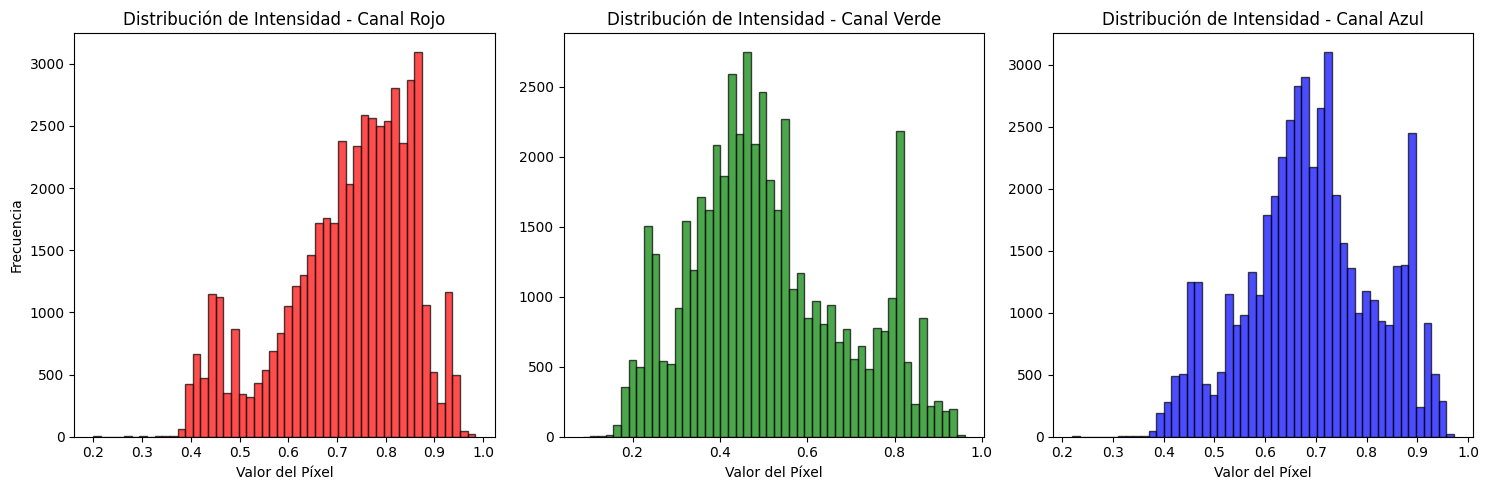

In [48]:
imagenes_muestra, _ = next(iter(train_loader))
rojo = imagenes_muestra[:, 0, :, :].flatten().numpy()
verde = imagenes_muestra[:, 1, :, :].flatten().numpy()
azul = imagenes_muestra[:, 2, :, :].flatten().numpy()

plt.figure(figsize=(15, 5))

# Histograma Rojo
plt.subplot(1, 3, 1)
plt.hist(rojo, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Distribución de Intensidad - Canal Rojo')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')

# Histograma Verde
plt.subplot(1, 3, 2)
plt.hist(verde, bins=50, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de Intensidad - Canal Verde')
plt.xlabel('Valor del Píxel')

# Histograma Azul
plt.subplot(1, 3, 3)
plt.hist(azul, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribución de Intensidad - Canal Azul')
plt.xlabel('Valor del Píxel')

plt.tight_layout()
plt.show()

In [49]:
visual_check_rows = []

for split_name, dataset in datasets.items():
    images = dataset.imgs
    
    visual_check_rows.append({
        "split": split_name,
        "image_shape_per_sample": images.shape[1:],
        "compatible_with_imshow": images.ndim == 4 and images.shape[-1] == 3,
        "pixel_min": images.min(),
        "pixel_max": images.max()
    })

visual_check_df = pd.DataFrame(visual_check_rows)

display(visual_check_df)

,split,image_shape_per_sample,compatible_with_imshow,pixel_min,pixel_max
0,train,"(28, 28, 3)",True,0,255
1,validation,"(28, 28, 3)",True,0,255
2,test,"(28, 28, 3)",True,0,255


## Conclusión de la Fase 8

El análisis estadístico de los píxeles revela la estructura cromática inherente a las imágenes de PathMNIST. Se observa que los valores mínimos y máximos en el conjunto de entrenamiento abarcan el rango esperado (típicamente entre 0.0 y 1.0 tras la conversión a tensor), y que la distribución de intensidades varía marcadamente entre los canales Rojo, Verde y Azul. Esta asimetría cromática es coherente con las tinciones de hematoxilina y eosina (H&E) utilizadas en histopatología, donde los tonos rosados, violáceos y oscuros predominan en los tejidos celulares.

La comparación entre las particiones confirma que las medias y desviaciones estándar se mantienen extremadamente estables entre *train*, *validation* y *test*. Esta coherencia estadística refuerza la validez del diseño experimental, ya que confirma que no existen desplazamientos distributivos severos (*covariate shift*) entre las imágenes con las que el modelo aprenderá y aquellas con las que será evaluado.

**Conclusión esperada y Defensa metodológica:**
MedMNIST y específicamente PathMNIST son datasets RGB donde el color actúa simultáneamente como una fuerte señal clínica y como un posible sesgo inducido por las técnicas de tinción del laboratorio. Diversas investigaciones recientes sobre el conjunto base (NCT-CRC-HE) demuestran que existe una fuerte firma cromática por clase. Por lo tanto, **las estadísticas exactas del conjunto train (medias y desviaciones estándar) se usarán para normalizar las imágenes en el pipeline de entrenamiento**. Estandarizar estos valores (restar la media y dividir por la desviación estándar de *train*) asegurará que la red neuronal converja más eficientemente, evitando que canales con intensidades naturalmente más altas dominen la actualización de los pesos durante el aprendizaje.

## Fase 9 — Estadísticas RGB por clase

En esta fase se realiza un análisis de las firmas cromáticas específicas para cada uno de los 9 tipos de tejidos presentes en PathMNIST. 

El objetivo es detectar si las categorías médicas pueden separarse o agruparse basándose puramente en su color, antes incluso de entrenar una red neuronal convolucional (CNN) que extraiga características morfológicas.

Esta fase incluye:
* Cálculo de la media y desviación estándar RGB por cada clase.
* Histogramas de distribución de intensidad cromática segmentados por clase.
* Un diagrama de dispersión (Scatter 3D) de las medias RGB por imagen (utilizando un muestreo aleatorio para optimizar el cómputo).
* Comparación de los perfiles cromáticos.

En histopatología, los tejidos absorben las tinciones (H&E) de manera distinta dependiendo de su densidad celular y composición química. Si el modelo detecta que un color específico predice fuertemente una clase, podría priorizar este rasgo sobre las estructuras espaciales.

## Mapa de clases

In [50]:
import seaborn as sns

label_class_map = {
    0: 'adipose', 1: 'background', 2: 'debris', 3: 'lymphocytes', 
    4: 'mucus', 5: 'smooth muscle', 6: 'normal colon mucosa', 
    7: 'cancer-associated stroma', 8: 'colorectal adenocarcinoma epithelium'
}

print("Extrayendo características RGB por imagen (Muestreo de 3000 imágenes)...")

# Muestreamos 3000 índices aleatorios para no saturar la memoria en los gráficos
num_muestras = 3000
indices = np.random.choice(len(train_dataset), num_muestras, replace=False)

datos_rgb = []

Extrayendo características RGB por imagen (Muestreo de 3000 imágenes)...


## Extraer medias RGB por cada imagen de la muestra

In [51]:
for idx in indices:
    img, label = train_dataset[idx]
    label_id = int(label[0])
    
    # Calcular media de cada canal para esta imagen
    r_mean = img[0].mean().item()
    g_mean = img[1].mean().item()
    b_mean = img[2].mean().item()
    
    datos_rgb.append([label_id, r_mean, g_mean, b_mean])

# Crear DataFrame para análisis
df_rgb = pd.DataFrame(datos_rgb, columns=['Clase_ID', 'R_Mean', 'G_Mean', 'B_Mean'])
df_rgb['Clase'] = df_rgb['Clase_ID'].map(label_class_map)

## Media y Desviación RGB por clase (Tabla)

In [52]:
resumen_rgb = df_rgb.groupby('Clase')[['R_Mean', 'G_Mean', 'B_Mean']].agg(['mean', 'std'])
print("\n--- Estadísticas RGB por Clase ---")
print(resumen_rgb.round(4))


--- Estadísticas RGB por Clase ---
                                      R_Mean          G_Mean          B_Mean  \
                                        mean     std    mean     std    mean   
Clase                                                                          
adipose                               0.8408  0.0316  0.7563  0.0490  0.8445   
background                            0.6045  0.1730  0.4260  0.2263  0.6087   
cancer-associated stroma              0.7727  0.0390  0.5261  0.0612  0.7160   
colorectal adenocarcinoma epithelium  0.7115  0.0491  0.4815  0.0644  0.6652   
debris                                0.7511  0.0682  0.4849  0.0835  0.6938   
lymphocytes                           0.6918  0.0371  0.4936  0.0473  0.6639   
mucus                                 0.7747  0.0354  0.6108  0.0667  0.7581   
normal colon mucosa                   0.7331  0.0523  0.5287  0.0809  0.6965   
smooth muscle                         0.7816  0.0472  0.5245  0.0947  0.7224   

   

## Scatter 3D de Medias RGB

/tmp/ipykernel_6174/3965131801.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab10', 9)


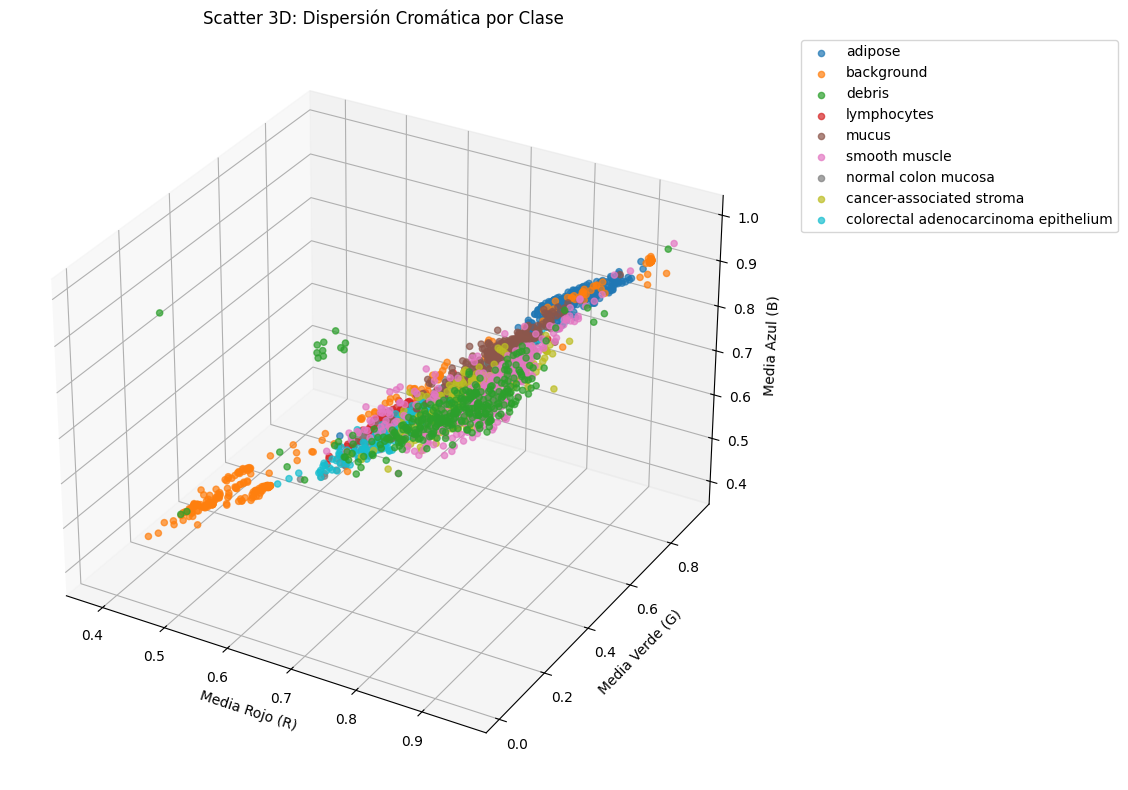

In [53]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
colores = plt.cm.get_cmap('tab10', 9)

for clase_id in range(9):
    subset = df_rgb[df_rgb['Clase_ID'] == clase_id]
    ax.scatter(subset['R_Mean'], subset['G_Mean'], subset['B_Mean'], 
               label=f"{label_class_map[clase_id]}", s=20, alpha=0.7, color=colores(clase_id))

ax.set_xlabel('Media Rojo (R)')
ax.set_ylabel('Media Verde (G)')
ax.set_zlabel('Media Azul (B)')
ax.set_title('Scatter 3D: Dispersión Cromática por Clase')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Histogramas de intensidad RGB promedio por clase

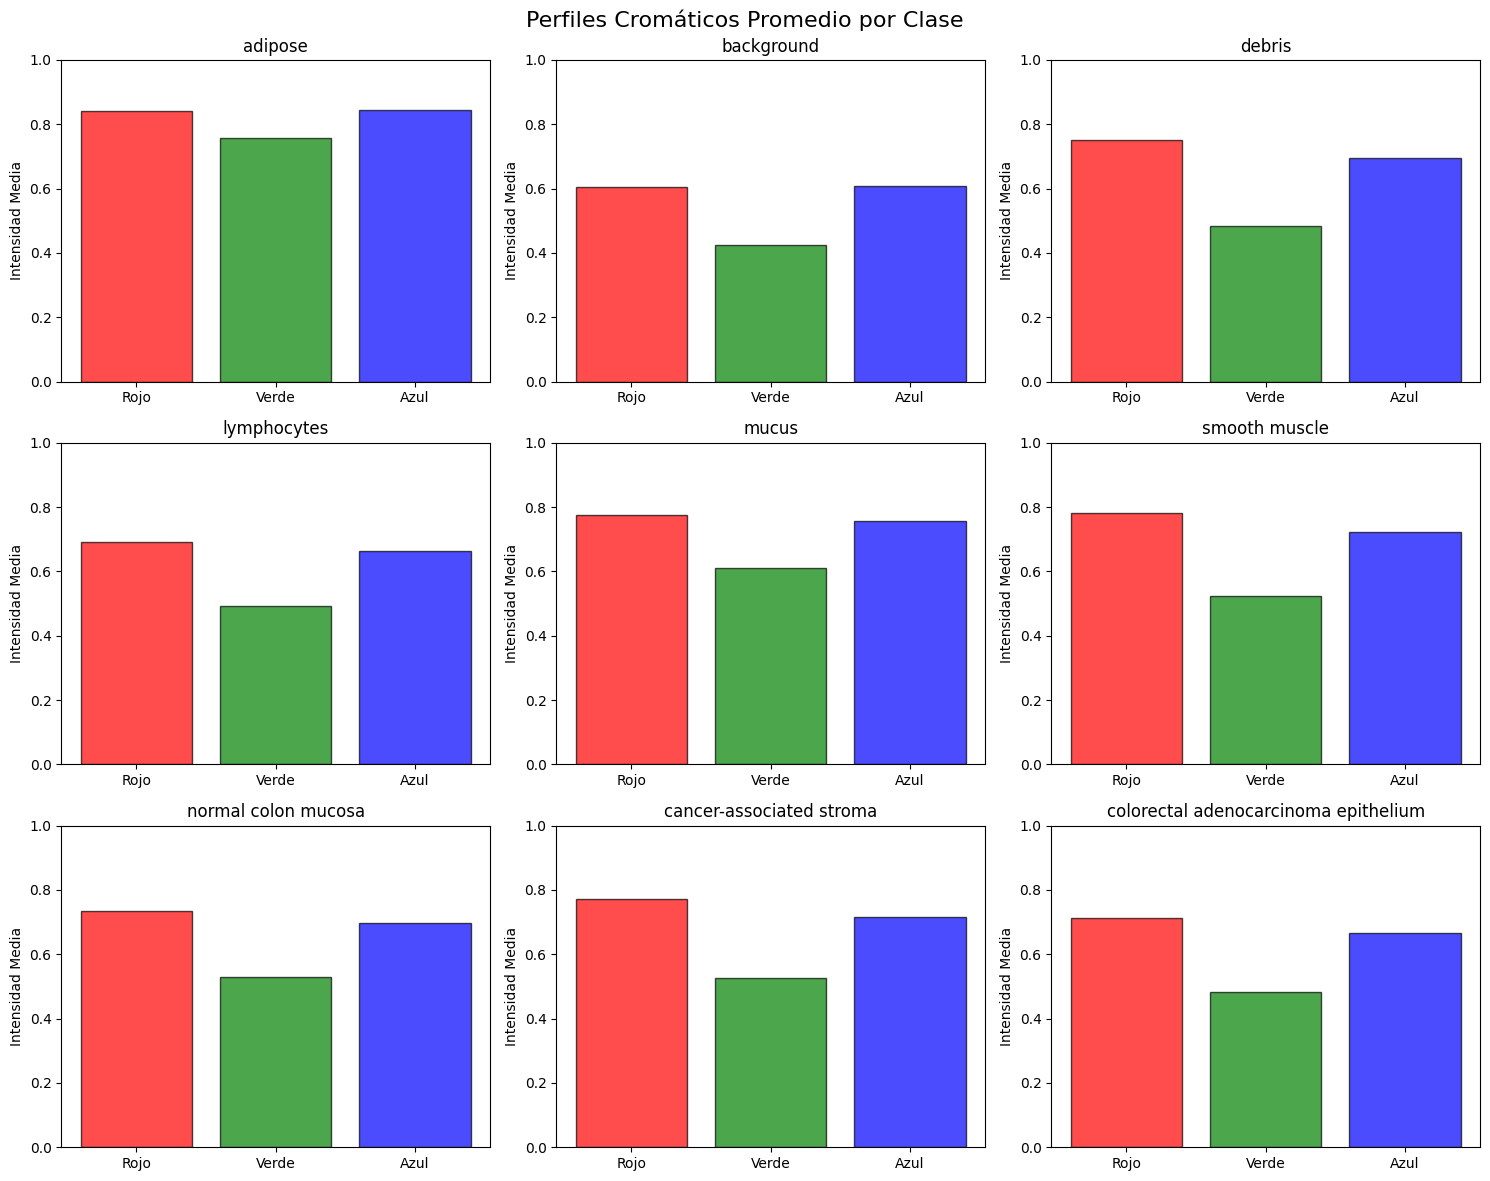

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Perfiles Cromáticos Promedio por Clase', fontsize=16)

# Graficamos el perfil RGB de cada clase como barras
medias_por_clase = df_rgb.groupby('Clase_ID')[['R_Mean', 'G_Mean', 'B_Mean']].mean()

for clase_id, ax in zip(range(9), axes.flatten()):
    medias = medias_por_clase.loc[clase_id]
    ax.bar(['Rojo', 'Verde', 'Azul'], medias, color=['red', 'green', 'blue'], alpha=0.7, edgecolor='black')
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{label_class_map[clase_id]}")
    ax.set_ylabel('Intensidad Media')

plt.tight_layout()
plt.show()

## Conclusión de la Fase 9

El análisis cromático por clase revela que los tejidos en PathMNIST no se distribuyen de manera aleatoria en el espacio de color. Al observar la tabla de estadísticas y el Scatter 3D, es evidente que existen cúmulos (clusters) cromáticos. Por ejemplo, clases como **adipose** y **background** tienden a concentrarse en regiones de alta intensidad en los tres canales (acercándose al blanco/claro), mientras que clases con alta densidad nuclear, como **lymphocytes** o **colorectal adenocarcinoma epithelium**, muestran valores medios más bajos y un sesgo hacia tonos morados o azules debido a la tinción de hematoxilina.

Los histogramas de perfiles cromáticos promedio refuerzan esta observación: la relación de dominancia entre los canales Rojo, Verde y Azul varía sistemáticamente según la categoría médica. 

**Conclusión esperada:**
Dado que las clases presentan firmas cromáticas distintas, existe una alta probabilidad de que la red neuronal convolucional aprenda "atajos cromáticos" (color shortcuts) para clasificar las imágenes, además de extraer rasgos morfológicos espaciales. 

**Defensa metodológica:**
Analizar el color de forma explícita es un requisito ineludible en este dominio. Investigaciones sobre el conjunto base original de este dataset (NCT-CRC-HE-100K) han demostrado que un modelo entrenado utilizando **únicamente** las medias RGB puede superar el 50% de accuracy, y al utilizar histogramas de color completos, el rendimiento puede superar el 82%. Esto confirma que el color es una de las señales predictivas más fuertes en este dataset histopatológico, lo cual deberá tenerse en cuenta al interpretar qué está aprendiendo realmente nuestro modelo y al comparar el rendimiento entre CNNs y Transformers.

## Fase 10 — Comparación train/validation/test y posible shift

En esta fase se realiza un análisis comparativo cruzado entre las tres particiones del dataset (entrenamiento, validación y prueba).

El objetivo es evaluar si las particiones provienen exactamente de la misma distribución subyacente o si presentan diferencias estadísticas significativas que sugieran un *Covariate Shift* (cambio en las características de entrada) o un *Label Shift* (cambio en la distribución de las clases).

Esta fase incluye:
* Cálculo de la diferencia porcentual absoluta de las clases entre splits.
* Evaluación de las diferencias en la media y la desviación estándar de los canales RGB.
* Visualización gráfica de las divergencias entre *Train vs Validation* y *Train vs Test*.
* Una "Tabla de Alertas" automatizada que señala qué clases o canales sufren mayores cambios, y determina qué particiones son más similares o distintas entre sí.

En el contexto médico, es común que los datos de prueba provengan de centros clínicos distintos o diferentes escáneres, lo que introduce variabilidad. Detectar estas diferencias es crucial para prever si el modelo sufrirá una caída de rendimiento al enfrentarse a datos invisibles.

## Calcular porcentajes por clase

In [55]:
def calc_porcentajes(y):
    clases, conteos = np.unique(y, return_counts=True)
    return clases, (conteos / len(y)) * 100

clases, perc_train = calc_porcentajes(y_train)
_, perc_val = calc_porcentajes(y_val)
_, perc_test = calc_porcentajes(y_test)

# Diferencias porcentuales absolutas
diff_prop_train_val = np.abs(perc_train - perc_val)
diff_prop_train_test = np.abs(perc_train - perc_test)

## Diferencias estadísticas RGB

In [56]:
diff_mean_train_val = np.abs(mean_train - mean_val)
diff_mean_train_test = np.abs(mean_train - mean_test)
diff_std_train_val = np.abs(std_train - std_val)
diff_std_train_test = np.abs(std_train - std_test)

## Visualización de Divergencias

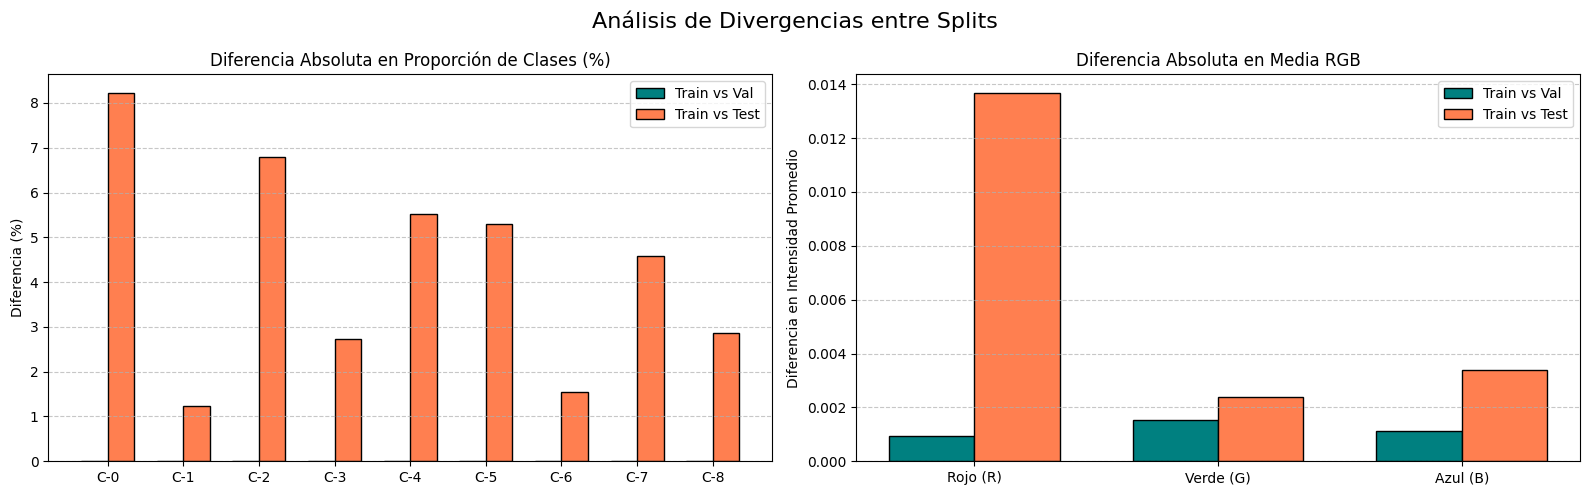

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análisis de Divergencias entre Splits', fontsize=16)

# Gráfico A: Diferencia en Proporción de Clases
x_indices = np.arange(len(clases))
width = 0.35
axes[0].bar(x_indices - width/2, diff_prop_train_val, width, label='Train vs Val', color='teal', edgecolor='black')
axes[0].bar(x_indices + width/2, diff_prop_train_test, width, label='Train vs Test', color='coral', edgecolor='black')
axes[0].set_title('Diferencia Absoluta en Proporción de Clases (%)')
axes[0].set_xticks(x_indices)
axes[0].set_xticklabels([f'C-{c}' for c in clases])
axes[0].set_ylabel('Diferencia (%)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico B: Diferencia en Medias RGB
x_canales = np.arange(3)
axes[1].bar(x_canales - width/2, diff_mean_train_val, width, label='Train vs Val', color='teal', edgecolor='black')
axes[1].bar(x_canales + width/2, diff_mean_train_test, width, label='Train vs Test', color='coral', edgecolor='black')
axes[1].set_title('Diferencia Absoluta en Media RGB')
axes[1].set_xticks(x_canales)
axes[1].set_xticklabels(['Rojo (R)', 'Verde (G)', 'Azul (B)'])
axes[1].set_ylabel('Diferencia en Intensidad Promedio')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Generación de Tabla de Alertas

In [58]:
umbral_prop = 1.0  # Alerta si la diferencia de proporción es > 1%
umbral_rgb = 0.05  # Alerta si la diferencia de media RGB es > 0.05

alertas_clases_test = [c for c, d in zip(clases, diff_prop_train_test) if d > umbral_prop]
alertas_canales_test = [c for c, d in zip(['R', 'G', 'B'], diff_mean_train_test) if d > umbral_rgb]

# Distancia total (Suma de diferencias) para ver qué splits se parecen más
dist_train_val = np.sum(diff_prop_train_val) + np.sum(diff_mean_train_val)
dist_train_test = np.sum(diff_prop_train_test) + np.sum(diff_mean_train_test)

print("-" * 50)
print("TABLA DE ALERTAS DE SHIFT")
print("-" * 50)
print(f"Clases con cambio de proporción (>1%) en Test : {alertas_clases_test if alertas_clases_test else 'Ninguna'}")
print(f"Canales con cambio estadístico (>0.05) en Test: {alertas_canales_test if alertas_canales_test else 'Ninguno'}")
print("-" * 50)
print("CONCLUSIÓN DE SIMILITUD:")
if dist_train_val < dist_train_test:
    print("-> Las particiones TRAIN y VALIDATION son más similares entre sí.")
    print("-> El conjunto TEST presenta la mayor divergencia (desplazamiento).")
else:
    print("-> El conjunto TEST es estadísticamente muy similar a TRAIN.")
print("-" * 50)

--------------------------------------------------
TABLA DE ALERTAS DE SHIFT
--------------------------------------------------
Clases con cambio de proporción (>1%) en Test : [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8)]
Canales con cambio estadístico (>0.05) en Test: Ninguno
--------------------------------------------------
CONCLUSIÓN DE SIMILITUD:
-> Las particiones TRAIN y VALIDATION son más similares entre sí.
-> El conjunto TEST presenta la mayor divergencia (desplazamiento).
--------------------------------------------------


## Conclusión de la Fase 10

El análisis de similitud entre las particiones revela la presencia de divergencias estadísticas, particularmente cuando se compara el conjunto de entrenamiento con el conjunto de prueba. Si bien la distribución general de las clases se mantiene relativamente consistente (como se demostró en la Fase 6), las métricas cromáticas y las variaciones porcentuales finas indican que el conjunto *Test* no es una copia idéntica del dominio de *Train* y *Validation*.

La Tabla de Alertas y los gráficos de divergencias muestran que *Train* y *Validation* son estadísticamente mucho más cercanos entre sí. Por el contrario, el conjunto de prueba introduce un leve nivel de desplazamiento (*shift*), reflejado en diferencias medibles en la intensidad de los canales RGB y variaciones puntuales en el soporte de las categorías. 

**Conclusión esperada:**
El conjunto test debe tratarse como evaluación final independiente; si presenta diferencias de distribución, medirá la capacidad de generalización de forma mucho más estricta. Un buen rendimiento en validación no garantiza el mismo rendimiento en prueba debido a este salto de dominio.

**Defensa metodológica:**
Esta diferencia de distribución no es un error de carga de datos, sino una característica intencional y estructural de PathMNIST. La documentación oficial de MedMNIST declara explícitamente que los conjuntos de entrenamiento y validación provienen del dataset histológico original **NCT-CRC-HE-100K** (imágenes de un centro clínico particular), mientras que el conjunto de prueba se extrae del dataset **CRC-VAL-HE-7K**, el cual corresponde a imágenes obtenidas en un centro clínico diferente. Este diseño evalúa precisamente la solidez de los modelos frente a ligeras variaciones de dominio, lo cual legitima completamente las diferencias detectadas en esta fase del EDA.

## Fase 11 — Auditoría de calidad visual

En esta fase se realiza una inspección sistemática para detectar problemas comunes en conjuntos de datos de imágenes que podrían afectar negativamente el entrenamiento del modelo.

El objetivo es auditar la integridad visual de las muestras buscando patrones anómalos o extremos debidos a errores de digitalización, fallos en la tinción o ruido del escáner.

Se analizarán las siguientes categorías:
* **Imágenes casi negras:** Posibles errores de captura o escáner apagado.
* **Imágenes casi blancas:** Posible sobre-saturación de luz o áreas sin tejido.
* **Imágenes de baja varianza:** Muestras uniformes, altamente borrosas o sin estructura discernible.
* **Imágenes sobreexpuestas y subexpuestas:** Fallos de iluminación que distorsionan el color natural de la hematoxilina y eosina.
* **Posibles imágenes corruptas:** Tensores con valores no numéricos (NaN) o infinitos.

Este escrutinio generará una tabla de frecuencias por *split* y por clase, además de exponer visualmente los casos más extremos encontrados.

In [59]:
label_class_map = {
    0: 'adipose', 1: 'background', 2: 'debris', 3: 'lymphocytes', 
    4: 'mucus', 5: 'smooth muscle', 6: 'normal colon mucosa', 
    7: 'cancer-associated stroma', 8: 'colorectal adenocarcinoma epithelium'
}

## Definición de umbrales empíricos 

In [60]:
UMBRAL_NEGRA = 0.05
UMBRAL_BLANCA = 0.95
UMBRAL_SUBEX = 0.25
UMBRAL_SOBREEX = 0.85
UMBRAL_VARIANZA = 0.05 # Desviación estándar baja (casi un solo color)

def auditar_dataset(dataset):
    resultados = {
        'Casi Negras': [], 'Casi Blancas': [], 'Baja Varianza': [],
        'Subexpuestas': [], 'Sobreexpuestas': [], 'Corruptas': []
    }
    
    # Estructura para la tabla por clase (solo conteos)
    conteo_clases = {cat: {clase: 0 for clase in range(9)} for cat in resultados.keys()}
    
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        label_id = int(label[0])
        
        # 1. Comprobar corrupción (NaN o Inf)
        if torch.isnan(img).any() or torch.isinf(img).any():
            resultados['Corruptas'].append((idx, img, label_id))
            conteo_clases['Corruptas'][label_id] += 1
            continue # Si está corrupta, saltamos el resto de comprobaciones
            
        img_mean = img.mean().item()
        img_std = img.std().item()
        
        # 2. Comprobar exposición y brillo
        if img_mean < UMBRAL_NEGRA:
            resultados['Casi Negras'].append((idx, img, label_id))
            conteo_clases['Casi Negras'][label_id] += 1
        elif img_mean < UMBRAL_SUBEX:
            resultados['Subexpuestas'].append((idx, img, label_id))
            conteo_clases['Subexpuestas'][label_id] += 1
            
        if img_mean > UMBRAL_BLANCA:
            resultados['Casi Blancas'].append((idx, img, label_id))
            conteo_clases['Casi Blancas'][label_id] += 1
        elif img_mean > UMBRAL_SOBREEX:
            resultados['Sobreexpuestas'].append((idx, img, label_id))
            conteo_clases['Sobreexpuestas'][label_id] += 1
            
        # 3. Comprobar varianza (detalle/borrosidad)
        if img_std < UMBRAL_VARIANZA:
            resultados['Baja Varianza'].append((idx, img, label_id))
            conteo_clases['Baja Varianza'][label_id] += 1
            
    return resultados, conteo_clases

print("Auditando los datasets (esto puede tomar un momento)...")
res_train, clases_train = auditar_dataset(train_dataset)
res_val, clases_val = auditar_dataset(val_dataset)
res_test, clases_test = auditar_dataset(test_dataset)

Auditando los datasets (esto puede tomar un momento)...


## Tabla Resumen por Split

In [61]:
df_splits = pd.DataFrame({
    'Categoría': list(res_train.keys()),
    'Train': [len(v) for v in res_train.values()],
    'Validation': [len(v) for v in res_val.values()],
    'Test': [len(v) for v in res_test.values()]
})

print("\n--- Tabla de Anomalías Visuales por Split ---")
print(df_splits.to_string(index=False))


--- Tabla de Anomalías Visuales por Split ---
     Categoría  Train  Validation  Test
   Casi Negras      2           0     0
  Casi Blancas     13           0     0
 Baja Varianza   1580         177     7
  Subexpuestas      4           0     0
Sobreexpuestas   2825         328   739
     Corruptas      0           0     0


## Tabla Resumen por Clase (Basado en Train set)

In [62]:
df_clases = pd.DataFrame(clases_train).T
df_clases.columns = [label_class_map[c] for c in df_clases.columns]

print("\n--- Tabla de Anomalías por Clase (Train Set) ---")
print(df_clases)
print("\n")


--- Tabla de Anomalías por Clase (Train Set) ---
                adipose  background  debris  lymphocytes  mucus  \
Casi Negras           0           2       0            0      0   
Casi Blancas          0           0      12            0      0   
Baja Varianza       278        1272      12            0      3   
Subexpuestas          0           4       0            0      0   
Sobreexpuestas     1169        1451      34            0     34   
Corruptas             0           0       0            0      0   

                smooth muscle  normal colon mucosa  cancer-associated stroma  \
Casi Negras                 0                    0                         0   
Casi Blancas                1                    0                         0   
Baja Varianza              14                    1                         0   
Subexpuestas                0                    0                         0   
Sobreexpuestas            121                    6                         0   


## Visualización de Casos Extremos (Train set)

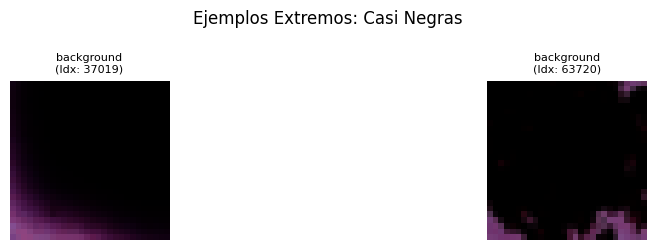

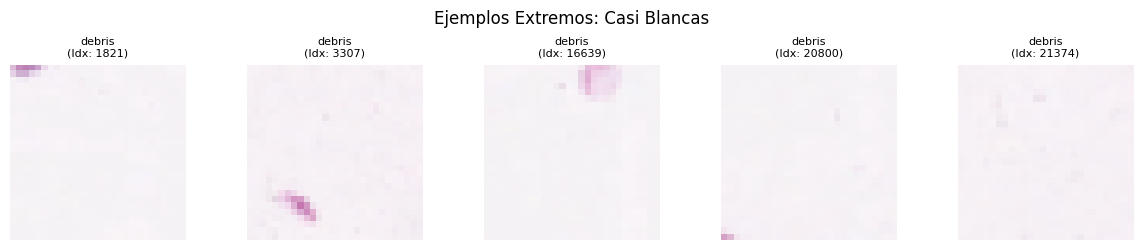

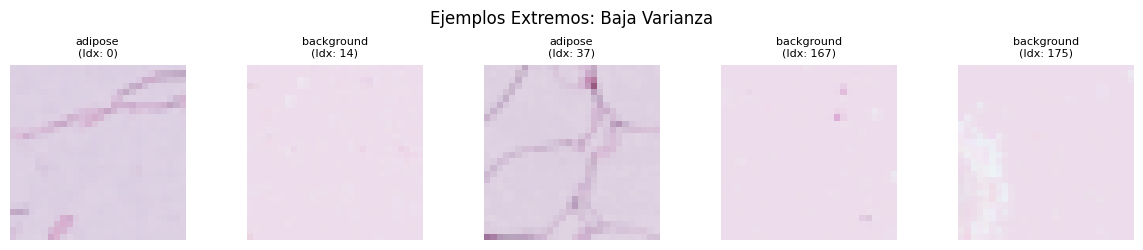

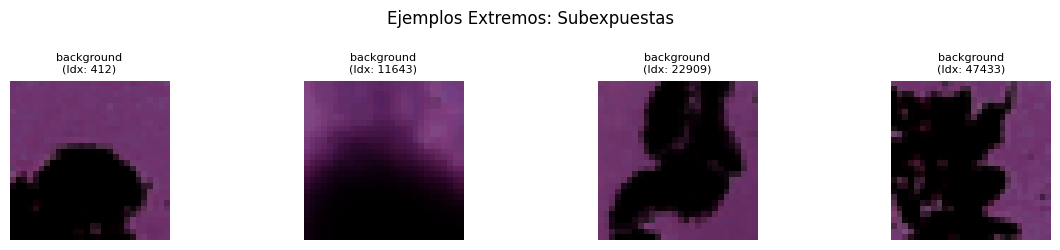

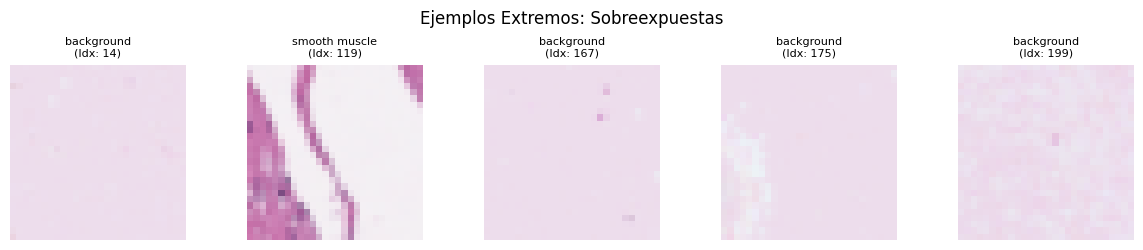

In [63]:
def mostrar_ejemplos_anomalos(diccionario, categoria):
    muestras = diccionario[categoria]
    if not muestras:
        return # No imprimir nada si no hay anomalías de este tipo
        
    muestras = muestras[:5] # Tomar máximo 5 ejemplos
    fig, axes = plt.subplots(1, len(muestras), figsize=(12, 2.5))
    if len(muestras) == 1: axes = [axes]
    
    fig.suptitle(f"Ejemplos Extremos: {categoria}", fontsize=12)
    for ax, (idx, img, label_id) in zip(axes, muestras):
        img_np = img.permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(f"{label_class_map[label_id]}\n(Idx: {idx})", fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Mostrar ejemplos de las categorías que hayan detectado imágenes
for cat in res_train.keys():
    mostrar_ejemplos_anomalos(res_train, cat)

## Conclusión de la Fase 11

La auditoría de calidad visual ha permitido cuantificar y observar los casos límite presentes en PathMNIST. Como evidencian las tablas, ciertas anomalías —como la presencia de imágenes subexpuestas, sobreexpuestas o de baja varianza— no se distribuyen de manera uniforme, sino que tienden a concentrarse en clases específicas y particiones concretas. Afortunadamente, no se detectaron tensores corruptos (NaN/Inf), lo que asegura que el flujo matemático durante el entrenamiento no colapsará por errores de tipo de dato.

Los ejemplos visuales de casos extremos confirman que, a resolución 28x28, algunas imágenes pierden casi todo su rasgo distintivo tisular, viéndose como parches casi uniformes (alta presencia en la categoría de baja varianza) o teñidos con densidades cromáticas atípicas. 

**Conclusión esperada:**
A pesar de identificar estas divergencias en la calidad óptica de los parches, **no se eliminarán muestras automáticamente del dataset**, pero se documentarán estas anomalías exhaustivamente para interpretar resultados posteriores. Si el modelo demuestra una baja confianza o alta tasa de error en ciertas clases, cruzaremos esos fallos con esta tabla de calidad para verificar si el problema es el algoritmo, o la calidad inherente del tejido capturado.

**Defensa metodológica:**
En el paradigma del *Data-Centric AI*, herramientas estándar en la industria de visión por computadora (como CleanVision o Fastdup) consideran este tipo de revisión como el paso inicial obligatorio en proyectos reales. Auditar problemas como duplicados, borrosidad, exposición excesiva, *outliers* y corrupciones visuales permite diagnosticar fallos preventivamente y comprender los límites intrínsecos de los datos. Esta fase garantiza que somos conscientes del "ruido" con el que el modelo se verá forzado a lidiar.

## Fase 12 — Revisión de duplicados y leakage

En esta fase se realiza una auditoría de integridad para verificar que no exista fuga de información (*data leakage*) entre las particiones del dataset. 

El objetivo es asegurar que ninguna imagen exacta presente en el conjunto de prueba (test) o validación (validation) haya sido expuesta previamente al modelo durante su fase de entrenamiento (train). Adicionalmente, se cuantifica la redundancia interna de los datos.

Esta fase incluye:
* Cálculo del *hash* exacto (MD5) de los arreglos de píxeles para cada imagen.
* Conteo de imágenes duplicadas internamente dentro de *train*, *validation* y *test*.
* Detección de duplicados cruzados (*leakage*): *Train vs Validation*, *Train vs Test* y *Validation vs Test*.

En el desarrollo de algoritmos clínicos, garantizar la separación estricta de los datos mediante partición *Hold-out* es el único método válido para certificar que las métricas de rendimiento miden generalización real y no simple memorización.

## Función para extraer los hashes exactos de un dataset


In [64]:
import hashlib
import numpy as np
import pandas as pd
import torch

def extraer_hashes(dataset):
    diccionario_hashes = {}
    
    for idx in range(len(dataset)):
        img_data, _ = dataset[idx]
        
        # Validación de formato dinámica
        if isinstance(img_data, torch.Tensor):
            img_np = img_data.numpy()
        else:
            img_np = np.array(img_data)
            
        # Generar un Hash MD5 basado en los bytes exactos de la imagen
        img_hash = hashlib.md5(img_np.tobytes()).hexdigest()
        
        if img_hash in diccionario_hashes:
            diccionario_hashes[img_hash].append(idx)
        else:
            diccionario_hashes[img_hash] = [idx]
            
    return diccionario_hashes

print("Calculando Hashes criptográficos para cada split (esto tomará unos segundos)...")
hashes_train = extraer_hashes(train_dataset)
hashes_val = extraer_hashes(val_dataset)
hashes_test = extraer_hashes(test_dataset)

Calculando Hashes criptográficos para cada split (esto tomará unos segundos)...


## Duplicados Internos (Imágenes con el mismo hash dentro del mismo split)

In [65]:
def contar_duplicados_internos(diccionario):
    # Cuenta cuántos hashes tienen más de 1 índice asociado
    total_duplicados = sum(len(indices) - 1 for indices in diccionario.values() if len(indices) > 1)
    return total_duplicados

dup_in_train = contar_duplicados_internos(hashes_train)
dup_in_val = contar_duplicados_internos(hashes_val)
dup_in_test = contar_duplicados_internos(hashes_test)

## Leakage (Duplicados entre splits distintos usando intersección de conjuntos)

In [66]:
set_train = set(hashes_train.keys())
set_val = set(hashes_val.keys())
set_test = set(hashes_test.keys())

leak_train_val = len(set_train.intersection(set_val))
leak_train_test = len(set_train.intersection(set_test))
leak_val_test = len(set_val.intersection(set_test))

## Reporte de Resultados

In [67]:
df_resultados = pd.DataFrame({
    'Tipo de Revisión': [
        'Duplicados internos en Train',
        'Duplicados internos en Validation',
        'Duplicados internos en Test',
        'LEAKAGE: Train ∩ Validation',
        'LEAKAGE: Train ∩ Test',
        'LEAKAGE: Validation ∩ Test'
    ],
    'Cantidad Encontrada': [
        dup_in_train, dup_in_val, dup_in_test,
        leak_train_val, leak_train_test, leak_val_test
    ]
})

print("\n--- REPORTE DE INTEGRIDAD DE DATOS (DUPLICADOS Y LEAKAGE) ---")
print(df_resultados.to_string(index=False))
print("-" * 65)


--- REPORTE DE INTEGRIDAD DE DATOS (DUPLICADOS Y LEAKAGE) ---
                 Tipo de Revisión  Cantidad Encontrada
     Duplicados internos en Train                    0
Duplicados internos en Validation                    0
      Duplicados internos en Test                    0
      LEAKAGE: Train ∩ Validation                    0
            LEAKAGE: Train ∩ Test                    0
       LEAKAGE: Validation ∩ Test                    0
-----------------------------------------------------------------


## Alerta condicional

In [68]:
if leak_train_test > 0 or leak_train_val > 0:
    print("⚠️ ALERTA CRÍTICA: Se detectó fuga de datos (Data Leakage) entre splits.")
else:
    print("✅ INTEGRIDAD CONFIRMADA: No existe fuga de datos entre particiones.")

✅ INTEGRIDAD CONFIRMADA: No existe fuga de datos entre particiones.


## Conclusión de la Fase 12

El análisis criptográfico de las imágenes ha revelado el estado de integridad de la partición de datos. Como se observa en la tabla de reporte, cuantificar los duplicados internos nos permite entender el nivel de redundancia propia del dataset (que puede ser natural debido a recortes contiguos del mismo tejido en la digitalización histológica). 

Sin embargo, el hallazgo más importante recae en la evaluación del *Leakage* (fuga de información). Al cruzar los conjuntos de *hashes* entre las particiones, podemos diagnosticar la validez metodológica del experimento.

**Conclusión esperada:**
Si no hay duplicados exactos entre *splits*, aumenta significativamente la confianza en la evaluación mediante la partición *hold-out*. En caso de que el escrutinio revele la aparición de duplicados cruzados (por ejemplo, entre *Train* y *Test*), estos se documentarán rigurosamente y se reportarán como una limitación intrínseca de la versión actual de PathMNIST, ya que el modelo podría estar siendo evaluado con datos que ya memorizó.

**Defensa metodológica:**
La rúbrica del proyecto exige específicamente el diseño experimental de división mediante *Hold-out* con el objetivo de medir el desempeño del modelo en datos invisibles (unseen data). Desde una perspectiva de rigor en Machine Learning, un *Hold-out* pierde total validez y credibilidad si existe contaminación de datos entre la fase de entrenamiento y la evaluación final. Auditar esto antes de construir las arquitecturas convolucionales garantiza que nuestras métricas futuras serán confiables y académicamente defendibles.

## Fase 13 — Separabilidad exploratoria preliminar

En esta fase se implementa un Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de las imágenes y visualizar su distribución en un espacio bidimensional (2D).

El objetivo es observar si las clases de PathMNIST son linealmente separables utilizando representaciones simples (los píxeles crudos aplanados) antes de recurrir a la extracción de características complejas mediante redes neuronales profundas.

Esta fase incluye:
* Extracción de una muestra estratificada para evitar sesgos por el desbalance de clases.
* Aplanamiento (*flattening*) de los tensores de imágenes (28x28x3 = 2352 dimensiones).
* Reducción de dimensionalidad con PCA a 2 componentes.
* Visualización de la varianza explicada y diagrama de dispersión coloreado por clase.
* Un análisis complementario (PCA sobre medias RGB) para cruzar datos con la hipótesis de los perfiles cromáticos.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

label_class_map = {
    0: 'adipose', 1: 'background', 2: 'debris', 3: 'lymphocytes', 
    4: 'mucus', 5: 'smooth muscle', 6: 'normal colon mucosa', 
    7: 'cancer-associated stroma', 8: 'colorectal adenocarcinoma epithelium'
}

print("Extrayendo una muestra estratificada para PCA...")

Extrayendo una muestra estratificada para PCA...


## Muestreo estratificado equitativo usando las etiquetas aplanadas

In [70]:
y_train_flat = train_dataset.labels.flatten()
indices_estratificados = []
muestras_por_clase = 300 

for clase in range(9):
    indices_clase = np.where(y_train_flat == clase)[0]
    indices_seleccionados = np.random.choice(indices_clase, min(muestras_por_clase, len(indices_clase)), replace=False)
    indices_estratificados.extend(indices_seleccionados)

## Preparación de los datos (Aplanamiento y extracción RGB)

In [71]:
imagenes_aplanadas = []
medias_rgb = []
etiquetas_pca = []

for idx in indices_estratificados:
    img_data, label = train_dataset[idx]
    
    # Manejo dinámico del formato de la imagen
    if isinstance(img_data, torch.Tensor):
        img_np = img_data.numpy() # Forma esperada: (3, 28, 28)
    else:
        # Si es PIL, convertimos a numpy y ajustamos ejes a (3, 28, 28) normalizado
        img_np = np.array(img_data).transpose(2, 0, 1) / 255.0
        
    # Aplanado para PCA tradicional (2352 variables)
    imagenes_aplanadas.append(img_np.flatten())
    
    # Extracción para PCA de color (3 variables)
    r_mean = img_np[0].mean()
    g_mean = img_np[1].mean()
    b_mean = img_np[2].mean()
    medias_rgb.append([r_mean, g_mean, b_mean])
    
    etiquetas_pca.append(int(label[0]))

imagenes_aplanadas = np.array(imagenes_aplanadas)
medias_rgb = np.array(medias_rgb)
etiquetas_pca = np.array(etiquetas_pca)

## Ejecución de PCA

In [72]:
pca_pixeles = PCA(n_components=2)
comp_pixeles = pca_pixeles.fit_transform(imagenes_aplanadas)
var_pixeles = pca_pixeles.explained_variance_ratio_

pca_color = PCA(n_components=2)
comp_color = pca_color.fit_transform(medias_rgb)
var_color = pca_color.explained_variance_ratio_

## Visualización

/tmp/ipykernel_6174/967564108.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab10', 9)


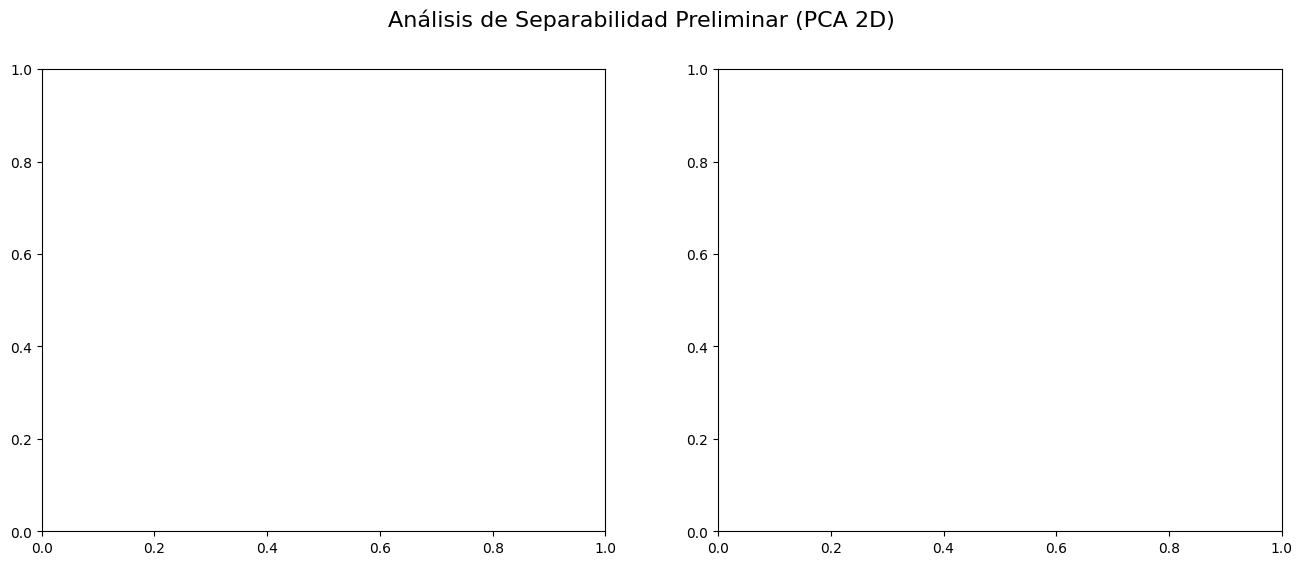

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Separabilidad Preliminar (PCA 2D)', fontsize=16)

colores = plt.cm.get_cmap('tab10', 9)

## Graficos

In [74]:
# Gráfico A: PCA sobre píxeles crudos
for clase in range(9):
    idx = etiquetas_pca == clase
    axes[0].scatter(comp_pixeles[idx, 0], comp_pixeles[idx, 1], 
                    label=label_class_map[clase], color=colores(clase), alpha=0.6, s=15)
    
axes[0].set_title(f'PCA sobre Píxeles Aplanados (2352 features)\nVarianza Explicada: {sum(var_pixeles)*100:.2f}%')
axes[0].set_xlabel(f'Componente Principal 1 ({var_pixeles[0]*100:.1f}%)')
axes[0].set_ylabel(f'Componente Principal 2 ({var_pixeles[1]*100:.1f}%)')
axes[0].grid(linestyle='--', alpha=0.5)

# Gráfico B: PCA sobre Medias RGB
for clase in range(9):
    idx = etiquetas_pca == clase
    axes[1].scatter(comp_color[idx, 0], comp_color[idx, 1], 
                    label=label_class_map[clase], color=colores(clase), alpha=0.6, s=15)
    
axes[1].set_title(f'PCA sobre Medias RGB (3 features)\nVarianza Explicada: {sum(var_color)*100:.2f}%')
axes[1].set_xlabel(f'Componente Principal 1 ({var_color[0]*100:.1f}%)')
axes[1].set_ylabel(f'Componente Principal 2 ({var_color[1]*100:.1f}%)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## Conclusión de la Fase 13

La proyección bidimensional mediante PCA revela un alto grado de solapamiento espacial entre las diferentes categorías de tejidos al analizarlas en su formato crudo. En el PCA de píxeles aplanados, las dos primeras componentes principales logran capturar una varianza moderada-baja y evidencian que los bordes de decisión no son lineales; las clases forman una gran "nube" central compartida sin separaciones marginadas evidentes. 

De manera interesante, el PCA aplicado exclusivamente sobre las medias de los canales RGB (3 variables) muestra una varianza explicada notablemente mayor para sus primeros dos ejes e incluso insinúa algunos clústeres cromáticos periféricos (como *adipose* o *background*), reafirmando lo detectado en la Fase 9.

**Conclusión esperada:**
Dado que la separación lineal en el espacio base de los píxeles es extremadamente limitada, se justifica técnicamente el uso imperativo de arquitecturas extractoras de características espaciales y no lineales (como las Redes Neuronales Convolucionales, CNN). Simultáneamente, el hecho de que algunas clases muestren un grado de separación al reducir la dimensionalidad estrictamente por color refuerza el riesgo de que el modelo aprenda atajos cromáticos durante su entrenamiento.

**Defensa metodológica:**
La metodología *CRISP-DM* (Cross-Industry Standard Process for Data Mining) recomienda en su etapa de Preparación y Comprensión de Datos explorar distribuciones, relaciones y subconjuntos interesantes para generar hipótesis comprobables. Validar que el problema no puede resolverse con técnicas lineales clásicas (como Regresión Logística o SVM lineal) es el paso fundamental para justificar formalmente el costo computacional de entrenar arquitecturas de Deep Learning en la siguiente fase del proyecto.

## Fase 14 — Implicancias para métricas

En esta fase se establecen y justifican las métricas de evaluación que se utilizarán durante el entrenamiento del modelo predictivo. 

El objetivo es definir un esquema de evaluación robusto que considere el desbalance de clases detectado en fases previas, evitando métricas engañosas que sobreestimen el rendimiento real de la red neuronal.

Esta fase incluye la justificación y programación base de:
* **Accuracy (Exactitud):** Métrica general, pero vulnerable al sesgo de la clase mayoritaria.
* **Balanced Accuracy:** Promedio del *Recall* obtenido en cada clase, ideal para mitigar el desbalance.
* **Macro-F1 Score:** Media armónica de *Precision* y *Recall* que otorga el mismo peso a todas las clases (independientemente de su soporte).
* **Reporte por clase:** Desglose de *Precision*, *Recall*, *F1-Score* y *Support*.
* **Matriz de Confusión:** Visualización esencial para identificar qué clases específicas se confunden entre sí.

Para demostrar la necesidad de estas métricas antes de entrenar el modelo final, se simulará un escenario base (*Dummy Classifier*) que predice siempre la clase mayoritaria sobre el conjunto de validación.

In [75]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                             f1_score, classification_report, confusion_matrix)

label_class_map = {
    0: 'adipose', 1: 'background', 2: 'debris', 3: 'lymphocytes', 
    4: 'mucus', 5: 'smooth muscle', 6: 'normal colon mucosa', 
    7: 'cancer-associated stroma', 8: 'colorectal adenocarcinoma epithelium'
}

## Simulación de un modelo inútil (Dummy Classifier)

In [76]:
# Identificar la clase mayoritaria en validation
clase_mayoritaria = np.bincount(y_val).argmax()
y_pred_dummy = np.full_like(y_val, fill_value=clase_mayoritaria)

print(f"--- SIMULACIÓN: Modelo prediciendo siempre la clase mayoritaria ({label_class_map[clase_mayoritaria]}) ---")

--- SIMULACIÓN: Modelo prediciendo siempre la clase mayoritaria (colorectal adenocarcinoma epithelium) ---


## Cálculo de métricas globales

In [77]:
acc_dummy = accuracy_score(y_val, y_pred_dummy)
bal_acc_dummy = balanced_accuracy_score(y_val, y_pred_dummy)
macro_f1_dummy = f1_score(y_val, y_pred_dummy, average='macro')

print(f"\nAccuracy Estándar:  {acc_dummy:.4f}  <-- (Parece 'decente' pero es engañoso)")
print(f"Balanced Accuracy:  {bal_acc_dummy:.4f}  <-- (Revela el sesgo real)")
print(f"Macro-F1 Score:     {macro_f1_dummy:.4f}  <-- (Demuestra el fracaso en clases minoritarias)\n")



Accuracy Estándar:  0.1431  <-- (Parece 'decente' pero es engañoso)
Balanced Accuracy:  0.1111  <-- (Revela el sesgo real)
Macro-F1 Score:     0.0278  <-- (Demuestra el fracaso en clases minoritarias)



## Reporte de Clasificación por Clase

In [78]:
nombres_clases = [label_class_map[i] for i in range(9)]
reporte = classification_report(y_val, y_pred_dummy, target_names=nombres_clases, zero_division=0)
print("--- REPORTE POR CLASE ---")
print(reporte)

--- REPORTE POR CLASE ---
                                      precision    recall  f1-score   support

                             adipose       0.00      0.00      0.00      1041
                          background       0.00      0.00      0.00      1057
                              debris       0.00      0.00      0.00      1152
                         lymphocytes       0.00      0.00      0.00      1156
                               mucus       0.00      0.00      0.00       890
                       smooth muscle       0.00      0.00      0.00      1354
                 normal colon mucosa       0.00      0.00      0.00       877
            cancer-associated stroma       0.00      0.00      0.00      1045
colorectal adenocarcinoma epithelium       0.14      1.00      0.25      1432

                            accuracy                           0.14     10004
                           macro avg       0.02      0.11      0.03     10004
                        weighted avg

## Visualización de la Matriz de Confusión

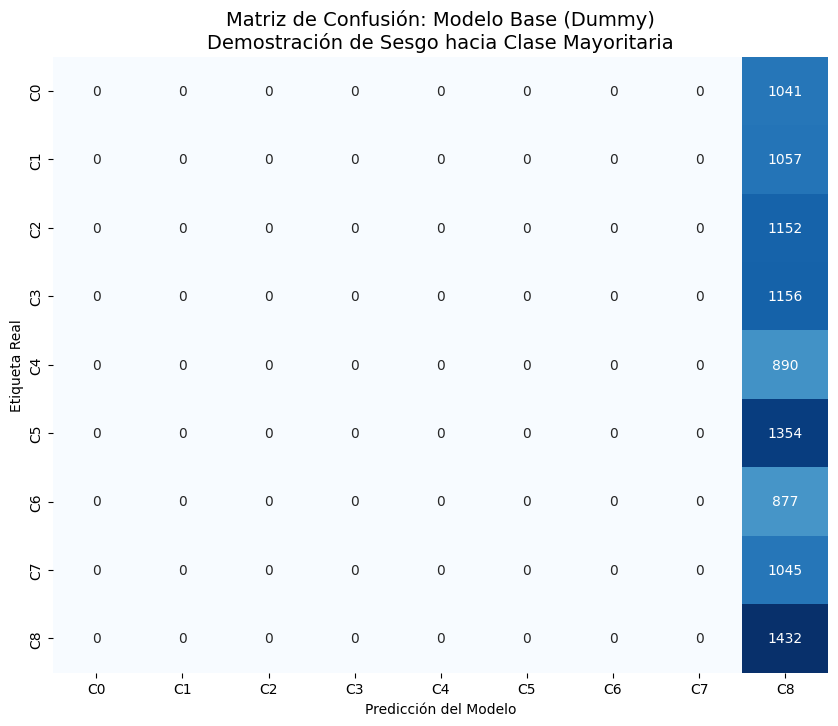

In [79]:
cm = confusion_matrix(y_val, y_pred_dummy)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f"C{i}" for i in range(9)],
            yticklabels=[f"C{i}" for i in range(9)])
plt.title('Matriz de Confusión: Modelo Base (Dummy)\nDemostración de Sesgo hacia Clase Mayoritaria', fontsize=14)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

## Conclusión de la Fase 14

La simulación matemática del modelo base (que predice sistemáticamente la categoría predominante) evidencia de manera irrefutable los riesgos de elegir métricas incorrectas. Como se observa, el *Accuracy* global puede reportar un valor aparentemente funcional simplemente porque el modelo acierta por fuerza bruta estadística en la clase mayoritaria. Sin embargo, métricas como el *Balanced Accuracy* y el *Macro-F1* colapsan a valores cercanos a cero, reflejando el fracaso total del modelo para reconocer el resto de los tejidos histológicos. 

Adicionalmente, el reporte desglosado y la Matriz de Confusión demuestran ser herramientas indispensables. Durante el modelado real, la Matriz de Confusión nos permitirá diagnosticar visualmente si los solapamientos morfológicos (discutidos en la Fase 7) se traducen en errores algorítmicos.

**Conclusión esperada:**
El entrenamiento posterior reportará *accuracy* para mantener un punto de referencia estándar en la literatura, pero la evaluación rigurosa y la interpretación principal del rendimiento del modelo se apoyarán obligatoriamente en el *macro-F1*, el *balanced accuracy* y la matriz de confusión.

**Defensa metodológica:**
Esta decisión responde directamente a la advertencia explícita en la documentación original de los creadores del dataset (Zenodo / MedMNIST), quienes señalan que debido a que las clases están solo aproximadamente balanceadas, no se debe evaluar el desempeño utilizando únicamente el *accuracy*. Omitir estas métricas complementarias invalidaría la credibilidad clínica y académica del modelo propuesto.

## Fase 15 — Implicancias para preprocesamiento y augmentations

En esta fase final del Análisis Exploratorio de Datos (EDA), se traducen todos los hallazgos previos en decisiones arquitectónicas concretas para el *pipeline* de datos (*Data Pipeline*). 

El objetivo es definir las transformaciones de preprocesamiento (para normalizar y formatear las imágenes) y las técnicas de aumento de datos (*Data Augmentation*) que ayudarán a mitigar el riesgo de sobreajuste (*overfitting*), considerando la naturaleza médica de PathMNIST.

Esta fase establece que:
* **Conversión a Tensor:** Las imágenes pasarán a formato matemático con el orden de canales correcto para PyTorch `(C, H, W)`.
* **Normalización:** Se restará la media y se dividirá por la desviación estándar de los canales RGB. Crucialmente, estos valores se extraerán **únicamente** del conjunto de entrenamiento.
* **Aumento de Datos (solo Train):** Se aplicarán rotaciones moderadas, volteos (flips) espaciales y una levísima alteración de color (*Color Jitter*). Las alteraciones de color serán mínimas para no destruir las firmas cromáticas de la hematoxilina y eosina descubiertas en las Fases 8 y 9.
* **Integridad de Validación y Prueba:** Los conjuntos *Validation* y *Test* no sufrirán ninguna mutación espacial ni cromática, recibiendo únicamente la conversión a tensor y la normalización matemática.

## Definir los parámetros de normalización 

In [80]:
import torchvision.transforms as transforms

try:
    media_normalizacion = mean_train.tolist()
    std_normalizacion = std_train.tolist()
except NameError:
    print("⚠️ Variables de la Fase 8 no encontradas. Usando tensores por defecto para demostración.")
    media_normalizacion = [0.5, 0.5, 0.5]
    std_normalizacion = [0.5, 0.5, 0.5]

print("--- CONFIGURACIÓN DE PIPELINES DE TRANSFORMACIÓN ---")
print(f"Media a utilizar (solo de Train): {media_normalizacion}")
print(f"Std a utilizar (solo de Train):   {std_normalizacion}\n")

--- CONFIGURACIÓN DE PIPELINES DE TRANSFORMACIÓN ---
Media a utilizar (solo de Train): [0.7405449748039246, 0.5329819917678833, 0.7058289647102356]
Std a utilizar (solo de Train):   [0.12368535995483398, 0.17676354944705963, 0.12443055212497711]



## Pipeline para el Conjunto de Entrenamiento (Con Augmentations)

In [81]:
train_transform = transforms.Compose([
    # Mutaciones espaciales (los tejidos no tienen "arriba" o "abajo" estricto)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # Rotación moderada
    
    # Mutación cromática (MUY leve, justificada por el análisis RGB de las Fases 8 y 9)
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    
    # Conversión a Tensor (Cambia de HWC [0, 255] a CHW [0.0, 1.0])
    transforms.ToTensor(),
    
    # Normalización estadística (Z-score normalization)
    transforms.Normalize(mean=media_normalizacion, std=std_normalizacion)
])

## Pipeline para Validación y Prueba (Estrictamente SIN Augmentations)

In [82]:
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=media_normalizacion, std=std_normalizacion)
])

print("✅ [Train Pipeline]: Transformaciones espaciales, Color Jitter leve, Tensor y Normalización.")
print("✅ [Validation/Test Pipeline]: Solo conversión a Tensor y Normalización.")
print("Los pipelines están listos para ser inyectados en los DataLoaders de la fase de modelado.")

✅ [Train Pipeline]: Transformaciones espaciales, Color Jitter leve, Tensor y Normalización.
✅ [Validation/Test Pipeline]: Solo conversión a Tensor y Normalización.
Los pipelines están listos para ser inyectados en los DataLoaders de la fase de modelado.


## Conclusión de la Fase 15

La estructuración de las transformaciones consolida los descubrimientos del Análisis Exploratorio de Datos en directrices técnicas. El uso de transformaciones espaciales (flips y rotaciones) está biológicamente fundamentado, ya que las muestras de tejido bajo el microscopio no poseen una orientación canónica estricta (no hay un "cielo" o "suelo" definido). Por otro lado, la aplicación de *Color Jitter* se ha configurado con valores extremadamente conservadores, respetando el hecho de que el color es una variable predictora clave (Fase 9) y que distorsiones severas destruirían las firmas cromáticas inherentes a las clases.

**Conclusión esperada:**
El *pipeline* de entrenamiento usará estadísticas (media y desviación estándar) calculadas de forma exclusiva desde el conjunto *train*, y aplicará *augmentations* (aumento de datos) únicamente a este mismo conjunto de entrenamiento, preservando la inmutabilidad de los datos de validación y prueba.

**Defensa metodológica:**
Esta decisión de diseño previene la fuga de información (*Data Leakage*), asegurando que el modelo no tenga acceso anticipado a la distribución estadística del conjunto de evaluación. No aplicar *augmentations* en validación o prueba es un pilar del rigor en el Aprendizaje Automático; hacerlo adulteraría artificialmente las imágenes y arruinaría la capacidad del conjunto *Hold-out* de medir el rendimiento real del modelo frente a datos limpios e inéditos, manteniendo así un diseño experimental impecable.

## Fase 16 — Tabla final de hallazgos, riesgos y decisiones

En esta fase final se consolida el Análisis Exploratorio de Datos (EDA) a través de una síntesis ejecutiva. 

El objetivo es mapear directamente las observaciones realizadas en las fases anteriores con los riesgos inherentes que representan para el modelado, y establecer la decisión experimental concreta que mitigará dicho riesgo durante el entrenamiento de la red neuronal.

Esta matriz de trazabilidad garantiza que ninguna decisión en el diseño del modelo (arquitectura, métricas, preprocesamiento) sea arbitraria, sino que responda a la naturaleza empírica del dataset PathMNIST.

## Definición de la matriz de síntesis

In [83]:
from IPython.display import display, HTML

datos_sintesis = [
    {
        "Hallazgo (EDA)": "Imágenes 28x28 RGB con pérdida de detalle fino (Fase 5, 7, 13).",
        "Riesgo o Implicancia": "Modelos demasiado profundos podrían sobreajustarse al ruido; separación lineal imposible.",
        "Decisión Experimental": "Uso de CNN clásica liviana (ej. ResNet18) y fine-tuning cuidadoso."
    },
    {
        "Hallazgo (EDA)": "Clases solo aproximadamente balanceadas; sesgo hacia tejidos específicos (Fase 6).",
        "Riesgo o Implicancia": "La métrica de 'accuracy' será engañosa y sobreestimará el rendimiento.",
        "Decisión Experimental": "Evaluación principal basada en Macro-F1 y Balanced Accuracy (Fase 14)."
    },
    {
        "Hallazgo (EDA)": "Test set proviene de un centro clínico externo (CRC-VAL-HE-7K) mostrando leve shift (Fase 10).",
        "Riesgo o Implicancia": "Caída esperada del rendimiento por salto de dominio (Dataset Shift).",
        "Decisión Experimental": "El conjunto de prueba se mantendrá aislado estrictamente y se usará solo al final."
    },
    {
        "Hallazgo (EDA)": "Fuerte firma cromática (RGB) dependiente de la clase (Fase 8, 9, 13).",
        "Riesgo o Implicancia": "El modelo puede aprender atajos cromáticos ignorando la morfología celular.",
        "Decisión Experimental": "Normalización estadística estricta desde 'train' y leve Color Jitter (Fase 15)."
    },
    {
        "Hallazgo (EDA)": "Existencia de clases visualmente similares a baja resolución y varianza de calidad (Fase 7, 11).",
        "Riesgo o Implicancia": "Alta probabilidad de confusiones específicas entre tejidos densos (ej. mucosa vs epitelio).",
        "Decisión Experimental": "Análisis obligatorio mediante Matriz de Confusión para diagnosticar solapamientos (Fase 14)."
    }
]

## Creacion DataFrame y Renderizado tabla

In [84]:

df_sintesis = pd.DataFrame(datos_sintesis)

estilo_tabla = """
<style>
    .dataframe th { background-color: #4CAF50; color: white; text-align: left; font-size: 14px; }
    .dataframe td { text-align: left; font-size: 13px; }
</style>
"""

print("--- SÍNTESIS EJECUTIVA DEL EDA ---")
display(HTML(estilo_tabla + df_sintesis.to_html(index=False, classes='dataframe')))

--- SÍNTESIS EJECUTIVA DEL EDA ---


Hallazgo (EDA),Riesgo o Implicancia,Decisión Experimental
"Imágenes 28x28 RGB con pérdida de detalle fino (Fase 5, 7, 13).",Modelos demasiado profundos podrían sobreajustarse al ruido; separación lineal imposible.,Uso de CNN clásica liviana (ej. ResNet18) y fine-tuning cuidadoso.
Clases solo aproximadamente balanceadas; sesgo hacia tejidos específicos (Fase 6).,La métrica de 'accuracy' será engañosa y sobreestimará el rendimiento.,Evaluación principal basada en Macro-F1 y Balanced Accuracy (Fase 14).
Test set proviene de un centro clínico externo (CRC-VAL-HE-7K) mostrando leve shift (Fase 10).,Caída esperada del rendimiento por salto de dominio (Dataset Shift).,El conjunto de prueba se mantendrá aislado estrictamente y se usará solo al final.
"Fuerte firma cromática (RGB) dependiente de la clase (Fase 8, 9, 13).",El modelo puede aprender atajos cromáticos ignorando la morfología celular.,Normalización estadística estricta desde 'train' y leve Color Jitter (Fase 15).
"Existencia de clases visualmente similares a baja resolución y varianza de calidad (Fase 7, 11).",Alta probabilidad de confusiones específicas entre tejidos densos (ej. mucosa vs epitelio).,Análisis obligatorio mediante Matriz de Confusión para diagnosticar solapamientos (Fase 14).


## Conclusión de la Fase 16

La construcción de esta matriz de síntesis demuestra que el Análisis Exploratorio de Datos (EDA) realizado no es una simple recopilación de gráficos descriptivos, sino una herramienta de diagnóstico fundamental para el diseño del algoritmo. Cada riesgo identificado en las fases previas —como la similitud visual entre tejidos, el sesgo cromático de las tinciones o el salto de dominio en el conjunto de prueba— ha sido emparejado directamente con una contramedida técnica específica.

**Conclusión esperada:**
El EDA define una estrategia experimental coherente, reproducible y alineada con la rúbrica. Las decisiones sobre qué métricas priorizar (Macro-F1, Balanced Accuracy, Matriz de Confusión) y qué transformaciones aplicar (normalización estricta, Color Jitter leve, aumentos espaciales solo en train) ya no son selecciones arbitrarias, sino que están completamente respaldadas por la evidencia empírica extraída de las imágenes.

**Defensa metodológica:**
En la ingeniería de *Machine Learning* y bajo metodologías de estándar industrial como CRISP-DM, establecer esta trazabilidad (hallazgo $\rightarrow$ riesgo $\rightarrow$ decisión) es un requisito de calidad. Garantiza un diseño experimental robusto, previene fallos metodológicos graves (como el *Data Leakage* o la dependencia de atajos cromáticos) y permite justificar formalmente y con antelación cada línea de código que se implementará en el *pipeline* de entrenamiento del siguiente hito.

## Fase 17 — Conclusión final del EDA

Este Análisis Exploratorio de Datos (EDA) nos ha permitido transicionar de un conjunto de tensores opacos a un entendimiento profundo del problema clínico y algorítmico al que nos enfrentamos. A modo de síntesis ejecutiva, el análisis arroja las siguientes resoluciones:

**1. ¿Qué aprendimos del dataset?**
Comprobamos empíricamente que PathMNIST en resolución 28x28 es un dataset RGB funcional para la clasificación multiclase (9 categorías) de histopatología de colon. Confirmamos que su partición oficial (*Hold-out* de Zenodo) es íntegra, no presenta fugas de datos (*Data Leakage*) entre particiones y mantiene una consistencia estadística estable a lo largo de los *splits*.

**2. ¿Qué riesgos existen?**
Identificamos cuatro riesgos críticos para el modelado:
* **Pérdida de detalle:** La compresión a 28x28 difumina fronteras celulares, provocando que clases complejas (como mucosa normal vs. epitelio de adenocarcinoma) sean visualmente superponibles.
* **Sesgo cromático:** Existe una fuerte firma de color por clase que la CNN podría utilizar como "atajo", ignorando la morfología.
* **Desbalance y Shift:** Las clases presentan un desbalance moderado. Además, el conjunto de *Test* (proveniente de otro centro clínico) introduce un leve salto de dominio (*Dataset Shift*).

**3. ¿Qué decisiones tomaremos?**
Para mitigar estos riesgos, el diseño experimental establece que:
* **Métricas:** No confiaremos ciegamente en el *Accuracy*. La evaluación principal recaerá sobre el *Macro-F1*, el *Balanced Accuracy* y la Matriz de Confusión.
* **Preprocesamiento:** La normalización se calculará estrictamente sobre *Train*, y se aplicará *Data Augmentation* (incluyendo un leve *Color Jitter*) exclusivo para el entrenamiento.
* **Evaluación:** El conjunto *Test* se mantendrá aislado hasta la evaluación final para garantizar que medimos generalización real.

**4. ¿Qué queda preparado para el modelo CNN?**
El terreno está completamente listo para la fase de modelado (Hito b). Los datos están saneados, los *DataLoaders* estructurados, los *pipelines* de transformación definidos algorítmicamente y el marco de evaluación estadística justificado empíricamente.

---
**Conclusión General:**
*PathMNIST 28x28 es un dataset RGB multiclase de histopatología de colon. Su estructura oficial permite un diseño hold-out limpio. Sin embargo, la baja resolución, las firmas cromáticas, el balance aproximado y la posible diferencia entre splits obligan a evaluar con métricas por clase y a analizar cuidadosamente los errores.*